# Architecture

In [1]:
# STAGE 1

import os, glob, random
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.model_selection import train_test_split

import torch
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
import torch, torch.nn as nn
import torch.nn.functional as F
from transformers import BeitModel
import seaborn as sns

# -------------------- SEED --------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------------------- IMAGE / TRAINING CONFIG --------------------
IMG_MTL   = 224
BATCH_MTL = 8
EPOCHS_MTL = 15
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BEST_STAGE1_PATH = "/kaggle/working/best_stage1.pth"

# -------------------- PATHS --------------------
PATH_CLS_TRAIN = "/kaggle/input/datasets/riyanka18/version-1-dataset/Training"
PATH_SEG_ROOT  = "/kaggle/input/brain-tumor-segmentation-dataset/Brain Tumor Segmentation Dataset"
PLOT_DIR = "/kaggle/working/plots_stage1"
os.makedirs(PLOT_DIR, exist_ok=True)

# -------------------- CLASS MAP --------------------
class_map = {
    "notumor": 0,
    "glioma": 1,
    "meningioma": 2,
    "pituitary": 3
}
inv_class_map = {v: k for k, v in class_map.items()}

cls_images, cls_labels = [], []

for cls_name, cls_id in class_map.items():
    folder = os.path.join(PATH_CLS_TRAIN, cls_name)
    for img_path in sorted(glob.glob(os.path.join(folder, "*"))):
        cls_images.append(img_path)
        cls_labels.append(cls_id)

cls_df_full = pd.DataFrame({
    "image": cls_images,
    "label": cls_labels
})

seg_rows = []
for cls_id in ["0", "1", "2", "3"]:
    img_dir  = os.path.join(PATH_SEG_ROOT, "image", cls_id)
    mask_dir = os.path.join(PATH_SEG_ROOT, "mask", cls_id)

    for img_path in sorted(glob.glob(os.path.join(img_dir, "*.jpg"))):
        fname = os.path.basename(img_path)
        mask_path = os.path.join(mask_dir, fname.replace(".jpg", "_m.jpg"))

        if os.path.exists(mask_path):
            seg_rows.append({
                "image": img_path,
                "mask_path": mask_path,
                "label": int(cls_id)
            })

seg_df_full = pd.DataFrame(seg_rows)

# ===============================
# SEGMENTATION TEST SPLIT (5%)
# ===============================
seg_test_rows = []

for cls_id in seg_df_full.label.unique():
    cls_subset = seg_df_full[seg_df_full.label == cls_id]
    n_test = max(1, int(0.05 * len(cls_subset)))
    seg_test_rows.append(cls_subset.sample(n_test, random_state=SEED))

# IMPORTANT: do NOT reset index yet
seg_test_df = pd.concat(seg_test_rows)

# Remove test samples using original indices
seg_df_remaining = seg_df_full.drop(seg_test_df.index)

# Now reset indices safely
seg_test_df = seg_test_df.reset_index(drop=True)
seg_df_remaining = seg_df_remaining.reset_index(drop=True)

print("SEG Test:", len(seg_test_df))
print(seg_test_df.label.value_counts().sort_index())


train_cls_df, val_cls_df = train_test_split(
    cls_df_full,
    test_size=0.2,
    stratify=cls_df_full.label,
    random_state=SEED
)

train_seg_df, val_seg_df = train_test_split(
    seg_df_remaining,
    test_size=0.15,
    random_state=SEED
)


def build_master_df(cls_df, seg_df):
    cls_map = {r.image: r.label for _, r in cls_df.iterrows()}
    seg_map = {r.image: r.mask_path for _, r in seg_df.iterrows()}

    all_imgs = sorted(set(cls_map) | set(seg_map))
    rows = []

    for img in all_imgs:
        rows.append({
            "image": img,
            "label": cls_map.get(img, -1),
            "mask_path": seg_map.get(img, None)
        })

    return pd.DataFrame(rows)

train_master_df = build_master_df(train_cls_df, train_seg_df)
val_master_df   = build_master_df(val_cls_df, val_seg_df)

# ==========================================================
# DATASET STATISTICS: CLASSIFICATION & SEGMENTATION
# ==========================================================

PATH_CLS_TEST = "/kaggle/input/datasets/riyanka18/version-1-dataset/Testing"

print("\n================ CLASSIFICATION COUNTS =================\n")

# ---------- Classification: Train / Val ----------
cls_train_counts = train_cls_df.label.value_counts().sort_index()
cls_val_counts   = val_cls_df.label.value_counts().sort_index()

# ---------- Classification: Test (folder-based) ----------
cls_test_counts = {}

for cls_name, cls_id in class_map.items():
    folder = os.path.join(PATH_CLS_TEST, cls_name)
    cls_test_counts[cls_id] = len(glob.glob(os.path.join(folder, "*")))

# ---------- Display ----------
print(f"{'Class':<12} {'Train':>8} {'Val':>8} {'Test':>8}")
print("-" * 40)

for cls_id in sorted(class_map.values()):
    cls_name = inv_class_map[cls_id]
    tr = cls_train_counts.get(cls_id, 0)
    va = cls_val_counts.get(cls_id, 0)
    te = cls_test_counts.get(cls_id, 0)
    print(f"{cls_name:<12} {tr:>8} {va:>8} {te:>8}")

print("-" * 40)
print(f"{'Total':<12} "
      f"{cls_train_counts.sum():>8} "
      f"{cls_val_counts.sum():>8} "
      f"{sum(cls_test_counts.values()):>8}")


print("\n================ SEGMENTATION PAIR COUNTS =================\n")

# ---------- Segmentation: Train / Val / Test ----------
seg_train_counts = train_seg_df.label.value_counts().sort_index()
seg_val_counts   = val_seg_df.label.value_counts().sort_index()
seg_test_counts  = seg_test_df.label.value_counts().sort_index()

print(f"{'Class':<12} {'Train':>8} {'Val':>8} {'Test':>8}")
print("-" * 40)

for cls_id in sorted(inv_class_map.keys()):
    cls_name = inv_class_map[cls_id]
    tr = seg_train_counts.get(cls_id, 0)
    va = seg_val_counts.get(cls_id, 0)
    te = seg_test_counts.get(cls_id, 0)
    print(f"{cls_name:<12} {tr:>8} {va:>8} {te:>8}")

print("-" * 40)
print(f"{'Total':<12} "
      f"{seg_train_counts.sum():>8} "
      f"{seg_val_counts.sum():>8} "
      f"{seg_test_counts.sum():>8}")


# ==========================================================

class MultiTaskDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.loc[idx]

        img = cv2.imread(row.image)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]

        if isinstance(row.mask_path, str) and os.path.exists(row.mask_path):
            mask = cv2.imread(row.mask_path, 0)
            mask = cv2.resize(mask, (w, h), interpolation=cv2.INTER_NEAREST)
            mask = (mask > 127).astype(np.float32)
        else:
            mask = np.zeros((h, w), dtype=np.float32)

        if self.transform:
            aug = self.transform(image=img, mask=mask)
            img, mask = aug["image"], aug["mask"]

        return img, torch.tensor(row.label), mask.unsqueeze(0)
train_tfms = A.Compose([
    A.Resize(IMG_MTL, IMG_MTL),
    A.HorizontalFlip(p=0.5),
    A.Normalize(mean=(0.485,0.456,0.406),
                std=(0.229,0.224,0.225)),
    ToTensorV2()
])

val_tfms = A.Compose([
    A.Resize(IMG_MTL, IMG_MTL),
    A.Normalize(mean=(0.485,0.456,0.406),
                std=(0.229,0.224,0.225)),
    ToTensorV2()
])

train_loader = DataLoader(
    MultiTaskDataset(train_master_df, train_tfms),
    batch_size=BATCH_MTL,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    MultiTaskDataset(val_master_df, val_tfms),
    batch_size=BATCH_MTL,
    shuffle=False,
    num_workers=2
)
# =========================
# CBAM ATTENTION MODULE
# =========================
class CBAM(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()

        # Channel Attention
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        self.fc = nn.Sequential(
            nn.Conv2d(channels, channels // reduction, 1, bias=False),
            nn.ReLU(),
            nn.Conv2d(channels // reduction, channels, 1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

        # Spatial Attention
        self.spatial = nn.Sequential(
            nn.Conv2d(2, 1, kernel_size=7, padding=3, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        identity = x  # keep original
    
        # ----- Channel Attention -----
        avg = self.fc(self.avg_pool(x))
        max_ = self.fc(self.max_pool(x))
        x = x * self.sigmoid(avg + max_)
    
        # ----- Spatial Attention -----
        avg = torch.mean(x, dim=1, keepdim=True)
        max_, _ = torch.max(x, dim=1, keepdim=True)
        spatial_attn = self.spatial(torch.cat([avg, max_], dim=1))
    
        x = x * spatial_attn  # ✅ APPLY, don't replace
        return x

# =========================
# ENCODER
# =========================
class BEiTEncoder(nn.Module):
    def __init__(self, model_name="microsoft/beit-base-patch16-224-pt22k", pretrained=True):
        super().__init__()
        self.model = BeitModel.from_pretrained(model_name) if pretrained \
                     else BeitModel.from_config(model_name)
        self.model.config.output_hidden_states = True

    def forward(self, x):
        outputs = self.model(x)
        hs = outputs.hidden_states

        feats = []
        for i in [-1, -2, -3, -4]:
            h = hs[i][:, 1:, :]
            b, n, c = h.shape

            H = W = int(np.sqrt(n))
            assert H * W == n, "Non-square feature map detected."

            h = h.permute(0, 2, 1).reshape(b, c, H, W)
            feats.append(h)

        return feats


# =========================
# DECODER (WITH CBAM + DEEP SUPERVISION)
# =========================
class SegFormerDecoder(nn.Module):
    def __init__(self, in_channels=[768]*4, embed_dim=512, num_classes=1):
        super().__init__()

        # Projection layers
        self.proj_layers = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(ch, embed_dim, 1, bias=False),
                nn.BatchNorm2d(embed_dim),
                nn.ReLU(inplace=True)
            ) for ch in in_channels
        ])

        # ✅ CBAM per scale
        self.cbam_blocks = nn.ModuleList([
            CBAM(embed_dim) for _ in range(4)
        ])

        # Fusion
        self.fuse = nn.Sequential(
            nn.Conv2d(embed_dim * 4, embed_dim, 3, padding=1, bias=False),
            nn.BatchNorm2d(embed_dim),
            nn.ReLU(inplace=True),

            nn.Conv2d(embed_dim, embed_dim, 3, padding=1, bias=False),
            nn.BatchNorm2d(embed_dim),
            nn.ReLU(inplace=True)
        )

        # ✅ CBAM after fusion
        self.cbam_fuse = CBAM(embed_dim)

        self.pred = nn.Conv2d(embed_dim, num_classes, 1)

    def forward(self, feats):
        target_size = feats[0].shape[2:]

        projected = []
        for i, f in enumerate(feats):
            x = self.proj_layers[i](f)

            # ✅ APPLY CBAM (per feature map)
            x = self.cbam_blocks[i](x)

            x = F.interpolate(x, size=target_size, mode="bilinear", align_corners=False)
            projected.append(x)

        fused = self.fuse(torch.cat(projected, dim=1))

        # ✅ APPLY CBAM after fusion
        fused = self.cbam_fuse(fused)

        # MAIN OUTPUT
        main_out = self.pred(fused)

        # AUX OUTPUTS (DEEP SUPERVISION)
        aux1 = self.pred(projected[1])
        aux2 = self.pred(projected[2])

        return main_out, aux1, aux2


# =========================
# MULTI-TASK MODEL
# =========================
class MultiTaskSegFormer(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.encoder = BEiTEncoder(pretrained=True)
        self.seg_decoder = SegFormerDecoder()

        self.classifier = nn.Linear(768, num_classes)

    def forward(self, x, enable_seg=True):
        feats = self.encoder(x)

        pooled = F.adaptive_avg_pool2d(feats[0], 1).flatten(1)
        cls_logits = self.classifier(pooled)

        if enable_seg:
            seg_outputs = self.seg_decoder(feats)

            if isinstance(seg_outputs, tuple):
                seg_outputs = list(seg_outputs)

            seg_outputs = [
                F.interpolate(o, size=x.shape[-2:], mode="bilinear", align_corners=False)
                for o in seg_outputs
            ]
        else:
            seg_outputs = None

        return cls_logits, seg_outputs


# =========================
# MODEL INIT
# =========================
model = MultiTaskSegFormer(num_classes=len(class_map)).to(device)
print("✅ Multi-task BEiT + SegFormer + CBAM + Deep Supervision initialized")
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)

        if probs.ndim == 4: probs = probs.squeeze(1)
        if targets.ndim == 4: targets = targets.squeeze(1)

        inter = (probs * targets).sum(dim=(1,2))
        union = probs.sum(dim=(1,2)) + targets.sum(dim=(1,2))

        return (1 - (2*inter + self.smooth)/(union + self.smooth)).mean()


class DiceFocalLoss(nn.Module):
    def __init__(self, alpha=0.8, gamma=2.0, smooth=1.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)

        if probs.ndim == 4: probs = probs.squeeze(1)
        if targets.ndim == 4: targets = targets.squeeze(1)

        inter = (probs * targets).sum(dim=(1,2))
        union = probs.sum(dim=(1,2)) + targets.sum(dim=(1,2))
        dice = 1 - (2*inter + self.smooth)/(union + self.smooth)

        bce = F.binary_cross_entropy_with_logits(
            logits.squeeze(1), targets, reduction="none"
        )
        pt = torch.exp(-bce)
        focal = self.alpha * (1 - pt) ** self.gamma * bce

        return dice.mean() + focal.mean()


cls_criterion = nn.CrossEntropyLoss()
seg_criterion = DiceFocalLoss()

optimizer = torch.optim.AdamW([
    {"params": model.encoder.parameters(), "lr": 1e-5},
    {"params": model.seg_decoder.parameters(), "lr": 2e-4},
    {"params": model.classifier.parameters(), "lr": 1e-4},
], weight_decay=5e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, factor=0.5, patience=3
)


def dice_batch_soft(preds, targets, eps=1e-6):
    preds = torch.sigmoid(preds)

    if preds.ndim == 4: preds = preds.squeeze(1)
    if targets.ndim == 4: targets = targets.squeeze(1)

    inter = (preds * targets).sum(dim=(1,2))
    union = preds.sum(dim=(1,2)) + targets.sum(dim=(1,2))

    return ((2*inter + eps)/(union + eps)).mean().item()

# =========================
# BLOCK 9 (FIXED + STABLE)
# =========================

scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

def classification_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    return acc, prec, rec, f1


def iou_batch_soft(preds, targets, eps=1e-6):
    preds = (preds.sigmoid() > 0.5).float()
    targets = targets.float()

    inter = (preds * targets).sum(dim=(1, 2, 3))
    union = (preds + targets - preds * targets).sum(dim=(1, 2, 3))

    return ((inter + eps) / (union + eps)).mean().item()


from torch import amp

# ---------------------------
# Deep supervision loss
# ---------------------------
def compute_deep_supervision_loss(seg_outputs, masks):
    if not isinstance(seg_outputs, list):
        seg_outputs = [seg_outputs]

    total_loss = 0.0

    for out in seg_outputs:
        if out.shape[-2:] != masks.shape[-2:]:
            out = F.interpolate(out, size=masks.shape[-2:], mode="bilinear", align_corners=False)
        total_loss += seg_criterion(out, masks)

    return total_loss / len(seg_outputs)


# ---------------------------
# TTA (FIXED for deep supervision)
# ---------------------------
def tta_seg_only(model, imgs):
    imgs_flip = torch.flip(imgs, dims=[3])

    _, seg1 = model(imgs)
    _, seg2 = model(imgs_flip)

    if isinstance(seg1, list) and isinstance(seg2, list):
        seg2 = [torch.flip(s, dims=[3]) for s in seg2]
        seg_out = [(s1 + s2) / 2 for s1, s2 in zip(seg1, seg2)]
    else:
        seg2 = torch.flip(seg2, dims=[3])
        seg_out = (seg1 + seg2) / 2

    return seg_out


# =========================
# TRAIN FUNCTION
# =========================
def train_multitask_plot(
    model,
    train_loader,
    val_loader,
    optimizer,
    scheduler,
    epochs,
    lambda_seg=1.0,
    grad_clip=1.0,
    checkpoint_path=BEST_STAGE1_PATH,
    initial_best_metric=None,
    stage_name="Stage-1",
    metric_mode="combined",
    seg_only=False
):

    best_metric = -1.0 if initial_best_metric is None else initial_best_metric

    history = {
        "train_loss": [], "train_cls_loss": [], "train_seg_loss": [],
        "train_acc": [], "train_f1": [], "train_dice": [], "train_iou": [],
        "val_loss": [], "val_acc": [], "val_f1": [], "val_dice": [], "val_iou": []
    }

    for epoch in range(epochs):

        # ===================== TRAIN =====================
        model.train()
        t_loss = t_cls = t_seg = 0.0
        train_preds, train_labels = [], []
        train_dices, train_ious = [], []

        for imgs, labels, masks in train_loader:
            imgs, labels, masks = imgs.to(device), labels.to(device), masks.to(device)

            with amp.autocast(device_type="cuda", enabled=torch.cuda.is_available()):

                # ✅ FIXED
                if seg_only:
                    seg_outputs = tta_seg_only(model, imgs)
                    cls_logits = None
                else:
                    cls_logits, seg_outputs = model(imgs)

                # ---- Classification loss
                if not seg_only:
                    valid_cls = (labels != -1)
                    cls_loss = (
                        cls_criterion(cls_logits[valid_cls], labels[valid_cls])
                        if valid_cls.any() else torch.tensor(0.0, device=device)
                    )
                else:
                    cls_loss = torch.tensor(0.0, device=device)

                # ---- Segmentation loss
                if masks.ndim == 3:
                    masks = masks.unsqueeze(1)

                has_mask = (masks.view(masks.size(0), -1).sum(1) > 0)

                if has_mask.any():
                    seg_loss = compute_deep_supervision_loss(
                        [o[has_mask] for o in seg_outputs] if isinstance(seg_outputs, list)
                        else seg_outputs[has_mask],
                        masks[has_mask]
                    )
                else:
                    seg_loss = torch.tensor(0.0, device=device)

                loss = lambda_seg * seg_loss if seg_only else cls_loss + lambda_seg * seg_loss

            optimizer.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            scaler.step(optimizer)
            scaler.update()

            t_loss += loss.item()
            t_cls += cls_loss.item()
            t_seg += seg_loss.item()

            # ---- Classification metrics
            if not seg_only and valid_cls.any():
                train_preds.extend(cls_logits[valid_cls].argmax(1).detach().cpu().numpy())
                train_labels.extend(labels[valid_cls].detach().cpu().numpy())

            # ---- Segmentation metrics
            final_seg = seg_outputs[-1] if isinstance(seg_outputs, list) else seg_outputs

            if has_mask.any():
                seg_pred = final_seg[has_mask].detach().cpu()
                seg_gt = masks[has_mask].detach().cpu()
                train_dices.append(dice_batch_soft(seg_pred, seg_gt))
                train_ious.append(iou_batch_soft(seg_pred, seg_gt))

        train_dice = np.mean(train_dices) if train_dices else 0.0
        train_iou  = np.mean(train_ious) if train_ious else 0.0

        # ===================== VALIDATION =====================
        model.eval()
        val_loss = 0.0
        val_preds, val_labels, val_dices, val_ious = [], [], [], []

        with torch.no_grad():
            for imgs, labels, masks in val_loader:
                imgs, labels, masks = imgs.to(device), labels.to(device), masks.to(device)

                with amp.autocast(device_type="cuda", enabled=torch.cuda.is_available()):

                    # ✅ FIXED
                    if seg_only:
                        seg_outputs = tta_seg_only(model, imgs)
                        cls_logits = None
                    else:
                        cls_logits, seg_outputs = model(imgs)

                final_seg = seg_outputs[-1] if isinstance(seg_outputs, list) else seg_outputs

                if final_seg.shape[-2:] != masks.shape[-2:]:
                    final_seg = F.interpolate(final_seg, size=masks.shape[-2:], mode="bilinear", align_corners=False)

                if not seg_only:
                    valid_cls = (labels != -1)
                    cls_loss = (
                        cls_criterion(cls_logits[valid_cls], labels[valid_cls])
                        if valid_cls.any() else torch.tensor(0.0, device=device)
                    )
                else:
                    cls_loss = torch.tensor(0.0, device=device)

                if masks.ndim == 3:
                    masks = masks.unsqueeze(1)

                has_mask = (masks.view(masks.size(0), -1).sum(1) > 0)

                if has_mask.any():
                    seg_loss = compute_deep_supervision_loss(seg_outputs, masks)
                else:
                    seg_loss = torch.tensor(0.0, device=device)

                loss = lambda_seg * seg_loss if seg_only else cls_loss + lambda_seg * seg_loss
                val_loss += loss.item()

                if not seg_only and valid_cls.any():
                    val_preds.extend(cls_logits[valid_cls].argmax(1).cpu().numpy())
                    val_labels.extend(labels[valid_cls].cpu().numpy())

                if has_mask.any():
                    seg_pred = final_seg[has_mask].cpu()
                    seg_gt = masks[has_mask].cpu()
                    val_dices.append(dice_batch_soft(seg_pred, seg_gt))
                    val_ious.append(iou_batch_soft(seg_pred, seg_gt))

        val_dice = np.mean(val_dices) if val_dices else 0.0
        val_iou  = np.mean(val_ious) if val_ious else 0.0

        # ---- Compute classification metrics FIRST
        train_acc, train_prec, train_rec, train_f1 = (
            classification_metrics(train_labels, train_preds)
            if len(train_labels) > 0 else (0, 0, 0, 0)
        )
        
        val_acc, val_prec, val_rec, val_f1 = (
            classification_metrics(val_labels, val_preds)
            if len(val_labels) > 0 else (0, 0, 0, 0)
        )

        # ===================== HISTORY =====================
        history["train_loss"].append(t_loss / len(train_loader))
        history["train_cls_loss"].append(t_cls / len(train_loader))
        history["train_seg_loss"].append(t_seg / len(train_loader))
        history["train_acc"].append(train_acc)
        history["train_f1"].append(train_f1)
        history["train_dice"].append(train_dice)
        history["train_iou"].append(train_iou)

        history["val_loss"].append(val_loss / len(val_loader))
        history["val_acc"].append(val_acc)
        history["val_f1"].append(val_f1)
        history["val_dice"].append(val_dice)
        history["val_iou"].append(val_iou)

        # ===================== LOG =====================
        print(
            f"[{stage_name} Epoch {epoch+1}/{epochs}] "
            f"TrainLoss {t_loss/len(train_loader):.4f} "
            f"TrainAcc {train_acc:.4f} F1 {train_f1:.4f} "
            f"Dice {train_dice:.4f} IoU {train_iou:.4f} || "
            f"ValLoss {val_loss/len(val_loader):.4f} "
            f"ValAcc {val_acc:.4f} F1 {val_f1:.4f} "
            f"Dice {val_dice:.4f} IoU {val_iou:.4f}"
        )

        try:
            scheduler.step(val_loss / len(val_loader))
        except:
            pass

        metric = val_dice if metric_mode == "dice" else (
            val_dice + val_iou if metric_mode == "dice_iou"
            else val_f1 + val_dice
        )

        if metric > best_metric:
            best_metric = metric
            torch.save(model.state_dict(), checkpoint_path)
            print(f"✅ [{stage_name}] BEST model saved (metric={metric:.4f})")
    # ======================================================
    # CLASSIFICATION REPORTS + CONFUSION MATRICES
    # ======================================================

    if not seg_only:
        class_names = list(class_map.keys())
    
        # -------- TRAIN --------
        print(f"\n=== {stage_name} Classification Report (TRAIN) ===")
        print(classification_report(
            train_labels, train_preds,
            target_names=class_names,
            zero_division=0
        ))
    
        plt.figure(figsize=(6,5))
        sns.heatmap(
            confusion_matrix(train_labels, train_preds),
            annot=True, fmt="d", cmap="Greens",
            xticklabels=class_names,
            yticklabels=class_names
        )
        plt.title(f"{stage_name} – Confusion Matrix (Train)")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.savefig(os.path.join(PLOT_DIR, f"{stage_name}_confusion_train.pdf"),
                    bbox_inches="tight")
        plt.close()
    
        # -------- VALIDATION --------
        print(f"\n=== {stage_name} Classification Report (VAL) ===")
        print(classification_report(
            val_labels, val_preds,
            target_names=class_names,
            zero_division=0
        ))
    
        plt.figure(figsize=(6,5))
        sns.heatmap(
            confusion_matrix(val_labels, val_preds),
            annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names
        )
        plt.title(f"{stage_name} – Confusion Matrix (Validation)")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.savefig(os.path.join(PLOT_DIR, f"{stage_name}_confusion_val.pdf"),
                    bbox_inches="tight")
        plt.close()       
        
    # ======================================================
    # LEARNING CURVES (SEPARATE PDFs)
    # ======================================================    
    def save_single_curve(train_vals, val_vals, title, ylabel, filename):
        plt.figure(figsize=(6,5))
    
        # 🔴 Train = RED
        plt.plot(train_vals,
                 color='red',
                 marker='o',
                 markersize=6,
                 linewidth=1.5,
                 label='Train')
    
        # 🔵 Validation = BLUE
        plt.plot(val_vals,
                 color='blue',
                 marker='o',
                 markersize=6,
                 linewidth=1.5,
                 label='Val')
    
        plt.xlabel("Epoch")
        plt.ylabel(ylabel)
        plt.title(title)
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.6)
    
        plt.tight_layout()
        plt.savefig(os.path.join(PLOT_DIR, filename), bbox_inches="tight")
        plt.close()
    # ---- Loss ----
    save_single_curve(history["train_loss"], history["val_loss"],
                          f"{stage_name} - Loss", "Loss",
                          f"{stage_name}_loss.pdf")
        
    # ---- Accuracy ----
    save_single_curve(history["train_acc"], history["val_acc"],
                          f"{stage_name} - Accuracy", "Accuracy",
                          f"{stage_name}_accuracy.pdf")
        
    # ---- F1 ----
    save_single_curve(history["train_f1"], history["val_f1"],
                          f"{stage_name} - F1 Score", "F1 Score",
                          f"{stage_name}_f1.pdf")
        
    # ---- Dice ----
    save_single_curve(history["train_dice"], history["val_dice"],
                          f"{stage_name} - Dice", "Dice",
                          f"{stage_name}_dice.pdf")
        
    # ---- IoU ----
    save_single_curve(history["train_iou"], history["val_iou"],
                          f"{stage_name} - IoU", "IoU",
                          f"{stage_name}_iou.pdf")
    return best_metric

2026-05-12 06:52:12.485116: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778568732.649155      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778568732.694474      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778568733.074737      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778568733.074776      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778568733.074779      57 computation_placer.cc:177] computation placer alr

SEG Test: 209
label
0    79
1    32
2    49
3    49
Name: count, dtype: int64

================ CLASSIFICATION COUNTS =================

Class           Train      Val     Test
----------------------------------------
notumor          1276      319      405
glioma           1057      264      300
meningioma       1071      268      306
pituitary        1165      292      300
----------------------------------------
Total            4569     1143     1311

================ SEGMENTATION PAIR COUNTS =================

Class           Train      Val     Test
----------------------------------------
notumor          1267      249       79
glioma            527       90       32
meningioma        813      137       49
pituitary         816      129       49
----------------------------------------
Total            3423      605      209


config.json:   0%|          | 0.00/736 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/368M [00:00<?, ?B/s]

Some weights of BeitModel were not initialized from the model checkpoint at microsoft/beit-base-patch16-224-pt22k and are newly initialized: ['pooler.layernorm.bias', 'pooler.layernorm.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ Multi-task BEiT + SegFormer + CBAM + Deep Supervision initialized


/tmp/ipykernel_57/1683403346.py:505: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())


# eval s1

In [2]:
# ======================================================
# BLOCK 10: EVALUATION + ROC–AUC + STAGE-1 + HOLD-OUT VIZ
# ======================================================

import torch
import torch.nn.functional as F
import cv2
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc


# ------------------------------------------------------
# 🔥 TTA FUNCTION
# ------------------------------------------------------
def tta_inference(model, imgs):
    imgs_flip = torch.flip(imgs, dims=[3])  # horizontal flip

    cls1, seg1 = model(imgs)
    cls2, seg2 = model(imgs_flip)

    # ---- Handle segmentation outputs (deep supervision)
    def get_final(seg):
        if seg is None:
            return None
        if isinstance(seg, list):
            return seg[-1]   # ✅ use FINAL output only
        return seg

    seg1 = get_final(seg1)
    seg2 = get_final(seg2)

    # reverse flip for segmentation
    if seg2 is not None:
        seg2 = torch.flip(seg2, dims=[3])

    cls_logits = (cls1 + cls2) / 2
    seg_logits = (seg1 + seg2) / 2 if seg1 is not None else None

    return cls_logits, seg_logits

# ------------------------------------------------------
# Combined metric = F1 (classification) + Dice (seg)
# ------------------------------------------------------
def evaluate_combined_metric(model, val_loader, use_tta=False):
    model.eval()
    val_preds, val_labels, val_dices = [], [], []

    with torch.no_grad():
        for imgs, labels, masks in val_loader:
            imgs, labels, masks = imgs.to(device), labels.to(device), masks.to(device)

            # 🔥 USE TTA HERE
            if use_tta:
                cls_logits, seg_logits = tta_inference(model, imgs)
            else:
                cls_logits, seg_logits = model(imgs)

            if seg_logits.shape[-2:] != masks.shape[-2:]:
                seg_logits = F.interpolate(
                    seg_logits, size=masks.shape[-2:], mode="bilinear", align_corners=False
                )

            valid_cls = (labels != -1)

            if masks.ndim == 3:
                masks = masks.unsqueeze(1)

            has_mask = (masks.view(masks.size(0), -1).sum(1) > 0)

            if valid_cls.any():
                val_preds.extend(cls_logits[valid_cls].argmax(1).cpu().numpy())
                val_labels.extend(labels[valid_cls].cpu().numpy())

            if has_mask.any():
                val_dices.append(
                    dice_batch_soft(
                        seg_logits[has_mask].cpu(),
                        masks[has_mask].cpu()
                    )
                )

    val_acc, _, _, val_f1 = (
        classification_metrics(val_labels, val_preds)
        if len(val_labels) > 0 else (0, 0, 0, 0)
    )
    val_dice = float(np.mean(val_dices)) if val_dices else 0.0

    return val_f1 + val_dice


# ------------------------------------------------------
# Dice-only (segmentation-only validation)
# ------------------------------------------------------
def evaluate_dice_only(model, val_loader, use_tta=False):
    model.eval()
    val_dices = []

    with torch.no_grad():
        for imgs, _, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)

            # 🔥 USE TTA HERE
            if use_tta:
                _, seg_logits = tta_inference(model, imgs)
            else:
                _, seg_logits = model(imgs)

            if seg_logits.shape[-2:] != masks.shape[-2:]:
                seg_logits = F.interpolate(
                    seg_logits, size=masks.shape[-2:], mode="bilinear", align_corners=False
                )

            if masks.ndim == 3:
                masks = masks.unsqueeze(1)

            has_mask = (masks.view(masks.size(0), -1).sum(1) > 0)

            if has_mask.any():
                val_dices.append(
                    dice_batch_soft(
                        seg_logits[has_mask].cpu(),
                        masks[has_mask].cpu()
                    )
                )

    return float(np.mean(val_dices)) if val_dices else 0.0


# ======================================================
# ROC–AUC HELPERS (NO CHANGE NEEDED)
# ======================================================
def collect_roc_data(model, loader, num_classes, device):
    model.eval()
    y_true, y_score = [], []

    with torch.no_grad():
        for imgs, labels, _ in loader:
            imgs, labels = imgs.to(device), labels.to(device)

            valid = (labels != -1)
            if not valid.any():
                continue

            cls_logits, _ = model(imgs[valid], enable_seg=False)
            probs = F.softmax(cls_logits, dim=1)

            y_true.extend(labels[valid].cpu().numpy())
            y_score.extend(probs.cpu().numpy())

    y_true = np.array(y_true)
    y_score = np.array(y_score)

    y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))
    return y_true_bin, y_score

# ======================================================
# STAGE-1 TRAINING (224 × 224)
# ======================================================
print("\n====== STAGE-1 TRAINING (224×224) ======\n")

best_metric_stage1 = train_multitask_plot(
    model,
    train_loader,
    val_loader,
    optimizer,
    scheduler,
    epochs=EPOCHS_MTL,
    lambda_seg=1.0,
    checkpoint_path=BEST_STAGE1_PATH,
    stage_name="Stage-1 (224px)",
    metric_mode="combined"
)

print(f"\n✅ STAGE-1 COMPLETE — BEST MODEL SAVED AT {BEST_STAGE1_PATH}\n")

# ======================================================
# 🔥 FINAL EVALUATION WITH TTA
# ======================================================
stage1_model = MultiTaskSegFormer(num_classes=len(class_map)).to(device)

stage1_model.load_state_dict(
    torch.load(BEST_STAGE1_PATH, map_location=device)
)

stage1_model.eval()

final_metric = evaluate_combined_metric(
    stage1_model,
    val_loader,
    use_tta=True
)

print(f"\n🚀 FINAL TTA METRIC (F1 + Dice): {final_metric:.4f}")


====== STAGE-1 TRAINING (224×224) ======

[Stage-1 (224px) Epoch 1/15] TrainLoss 1.6619 TrainAcc 0.7472 F1 0.7412 Dice 0.4218 IoU 0.3869 || ValLoss 0.2709 ValAcc 0.9230 F1 0.9201 Dice 0.7056 IoU 0.6090
✅ [Stage-1 (224px)] BEST model saved (metric=1.6257)
[Stage-1 (224px) Epoch 2/15] TrainLoss 0.6023 TrainAcc 0.9212 F1 0.9190 Dice 0.7466 IoU 0.6512 || ValLoss 0.1562 ValAcc 0.9554 F1 0.9543 Dice 0.8115 IoU 0.7185
✅ [Stage-1 (224px)] BEST model saved (metric=1.7658)
[Stage-1 (224px) Epoch 3/15] TrainLoss 0.4116 TrainAcc 0.9569 F1 0.9556 Dice 0.8114 IoU 0.7187 || ValLoss 0.1398 ValAcc 0.9703 F1 0.9692 Dice 0.8328 IoU 0.7468
✅ [Stage-1 (224px)] BEST model saved (metric=1.8020)
[Stage-1 (224px) Epoch 4/15] TrainLoss 0.3097 TrainAcc 0.9744 F1 0.9737 Dice 0.8416 IoU 0.7542 || ValLoss 0.1538 ValAcc 0.9685 F1 0.9673 Dice 0.8517 IoU 0.7700
✅ [Stage-1 (224px)] BEST model saved (metric=1.8190)
[Stage-1 (224px) Epoch 5/15] TrainLoss 0.2697 TrainAcc 0.9781 F1 0.9776 Dice 0.8584 IoU 0.7759 || ValLoss

Some weights of BeitModel were not initialized from the model checkpoint at microsoft/beit-base-patch16-224-pt22k and are newly initialized: ['pooler.layernorm.bias', 'pooler.layernorm.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



🚀 FINAL TTA METRIC (F1 + Dice): 1.8685


# stage 2

In [3]:
# ======================================================
# STAGE-2 CONFIG (Mixed Tumor + Few Background)
# ======================================================
IMG_STAGE2   = 384
BATCH_STAGE2 = 4
EPOCHS_STAGE2 = 5
LAMBDA_SEG_STAGE2 = 3.0

STAGE2_CKPT_PATH = "/kaggle/working/best_stage2_segmentation.pth"

# -------------------------------
# 1️⃣ Select tumor samples
# -------------------------------
train_tumor = train_seg_df[train_seg_df.label != 0]
val_tumor   = val_seg_df[val_seg_df.label != 0]

# -------------------------------
# 2️⃣ Sample a few background (label 0)
# -------------------------------
BG_RATIO = 0.10   # 👈 10% background relative to tumor count

train_bg = train_seg_df[train_seg_df.label == 0].sample(
    n=int(len(train_tumor) * BG_RATIO),
    random_state=SEED
)

val_bg = val_seg_df[val_seg_df.label == 0].sample(
    n=int(len(val_tumor) * BG_RATIO),
    random_state=SEED
)

# -------------------------------
# 3️⃣ Combine
# -------------------------------
train_seg_stage2 = pd.concat([train_tumor, train_bg]).sample(frac=1.0, random_state=SEED).reset_index(drop=True)
val_seg_stage2   = pd.concat([val_tumor, val_bg]).sample(frac=1.0, random_state=SEED).reset_index(drop=True)

print("Stage-2 TRAIN mixed counts:")
print(train_seg_stage2.label.value_counts().sort_index())

print("\nStage-2 VAL mixed counts:")
print(val_seg_stage2.label.value_counts().sort_index())


class SegOnlyDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.loc[idx]

        img = cv2.imread(row.image)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]

        mask = cv2.imread(row.mask_path, 0)
        mask = cv2.resize(mask, (w, h), interpolation=cv2.INTER_NEAREST)
        mask = (mask > 127).astype(np.float32)

        if self.transform:
            aug = self.transform(image=img, mask=mask)
            img, mask = aug["image"], aug["mask"]

        return img, torch.tensor(-1), mask.unsqueeze(0)

train_tfms_stage2 = A.Compose([
    A.Resize(IMG_STAGE2, IMG_STAGE2),
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.1,
        rotate_limit=15,
        p=0.5
    ),
    A.Normalize(mean=(0.485,0.456,0.406),
                std=(0.229,0.224,0.225)),
    ToTensorV2()
])

val_tfms_stage2 = A.Compose([
    A.Resize(IMG_STAGE2, IMG_STAGE2),
    A.Normalize(mean=(0.485,0.456,0.406),
                std=(0.229,0.224,0.225)),
    ToTensorV2()
])
train_loader_stage2 = DataLoader(
    SegOnlyDataset(train_seg_stage2, train_tfms_stage2),
    batch_size=BATCH_STAGE2,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader_stage2 = DataLoader(
    SegOnlyDataset(val_seg_stage2, val_tfms_stage2),
    batch_size=BATCH_STAGE2,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)
def iou_batch_soft(preds, targets, eps=1e-6):
    preds = torch.sigmoid(preds)

    if preds.ndim == 4: preds = preds.squeeze(1)
    if targets.ndim == 4: targets = targets.squeeze(1)

    inter = (preds * targets).sum(dim=(1,2))
    union = preds.sum(dim=(1,2)) + targets.sum(dim=(1,2)) - inter

    return ((inter + eps) / (union + eps)).mean().item()
stage2_model = MultiTaskSegFormer(num_classes=len(class_map)).to(device)
stage2_model.load_state_dict(torch.load(BEST_STAGE1_PATH, map_location=device))
print("✅ Stage-1 weights loaded into Stage-2 model")
optimizer_stage2 = torch.optim.AdamW([
    {"params": stage2_model.encoder.parameters(), "lr": 5e-6},
    {"params": stage2_model.seg_decoder.parameters(), "lr": 2e-4},
], weight_decay=1e-4)

scheduler_stage2 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_stage2, factor=0.5, patience=2
)
best_stage2_dice = train_multitask_plot(
    model=stage2_model,
    train_loader=train_loader_stage2,
    val_loader=val_loader_stage2,
    optimizer=optimizer_stage2,
    scheduler=scheduler_stage2,
    epochs=EPOCHS_STAGE2,
    lambda_seg=LAMBDA_SEG_STAGE2,
    grad_clip=1.0,
    checkpoint_path=STAGE2_CKPT_PATH,
    stage_name="Stage-2 Tumor-Only Segmentation",
    metric_mode="dice",
    seg_only=True
)
# ======================================================
# ROC–AUC HELPERS
# ======================================================
def collect_roc_data(model, loader, num_classes, device):
    model.eval()
    y_true, y_score = [], []

    with torch.no_grad():
        for imgs, labels, _ in loader:
            imgs, labels = imgs.to(device), labels.to(device)

            valid = (labels != -1)
            if not valid.any():
                continue

            cls_logits, _ = model(imgs[valid], enable_seg=False)
            probs = F.softmax(cls_logits, dim=1)

            y_true.extend(labels[valid].cpu().numpy())
            y_score.extend(probs.cpu().numpy())

    y_true = np.array(y_true)
    y_score = np.array(y_score)

    y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))
    return y_true_bin, y_score


def plot_train_vs_val_roc(
    model, train_loader, val_loader, num_classes, inv_class_map, device
):
    y_train_bin, y_train_score = collect_roc_data(
        model, train_loader, num_classes, device
    )
    y_val_bin, y_val_score = collect_roc_data(
        model, val_loader, num_classes, device
    )

    plt.figure(figsize=(7, 5))

    for i in range(num_classes):
        fpr_t, tpr_t, _ = roc_curve(y_train_bin[:, i], y_train_score[:, i])
        fpr_v, tpr_v, _ = roc_curve(y_val_bin[:, i], y_val_score[:, i])

        plt.plot(
            fpr_t, tpr_t, "--",
            label=f"Train {inv_class_map[i]} (AUC={auc(fpr_t, tpr_t):.2f})"
        )
        plt.plot(
            fpr_v, tpr_v, "-",
            label=f"Val {inv_class_map[i]} (AUC={auc(fpr_v, tpr_v):.2f})"
        )

    plt.plot([0, 1], [0, 1], "k--", linewidth=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Stage-2 ROC–AUC (Train vs Validation)")
    plt.legend(fontsize=8)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    roc_path = os.path.join(PLOT_DIR, "stage2_roc_auc_new.pdf")
    plt.savefig(roc_path, bbox_inches="tight")
    plt.close()

stage2_model = MultiTaskSegFormer(num_classes=len(class_map)).to(device)
stage2_model.load_state_dict(torch.load("/kaggle/working/best_stage2_segmentation.pth", map_location=device))
stage2_model.eval()

plot_train_vs_val_roc(
    stage2_model, train_loader, val_loader,
    num_classes=len(class_map),
    inv_class_map=inv_class_map,
    device=device
)

Stage-2 TRAIN mixed counts:
label
0    215
1    527
2    813
3    816
Name: count, dtype: int64

Stage-2 VAL mixed counts:
label
0     35
1     90
2    137
3    129
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
Some weights of BeitModel were not initialized from the model checkpoint at microsoft/beit-base-patch16-224-pt22k and are newly initialized: ['pooler.layernorm.bias', 'pooler.layernorm.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ Stage-1 weights loaded into Stage-2 model
[Stage-2 Tumor-Only Segmentation Epoch 1/5] TrainLoss 0.4310 TrainAcc 0.0000 F1 0.0000 Dice 0.8710 IoU 0.7884 || ValLoss 0.6160 ValAcc 0.0000 F1 0.0000 Dice 0.8884 IoU 0.8127
✅ [Stage-2 Tumor-Only Segmentation] BEST model saved (metric=0.8884)
[Stage-2 Tumor-Only Segmentation Epoch 2/5] TrainLoss 0.3437 TrainAcc 0.0000 F1 0.0000 Dice 0.8957 IoU 0.8202 || ValLoss 0.6063 ValAcc 0.0000 F1 0.0000 Dice 0.8946 IoU 0.8225
✅ [Stage-2 Tumor-Only Segmentation] BEST model saved (metric=0.8946)
[Stage-2 Tumor-Only Segmentation Epoch 3/5] TrainLoss 0.3192 TrainAcc 0.0000 F1 0.0000 Dice 0.9030 IoU 0.8306 || ValLoss 0.6098 ValAcc 0.0000 F1 0.0000 Dice 0.8937 IoU 0.8230
[Stage-2 Tumor-Only Segmentation Epoch 4/5] TrainLoss 0.3039 TrainAcc 0.0000 F1 0.0000 Dice 0.9074 IoU 0.8373 || ValLoss 0.5840 ValAcc 0.0000 F1 0.0000 Dice 0.8983 IoU 0.8282
✅ [Stage-2 Tumor-Only Segmentation] BEST model saved (metric=0.8983)
[Stage-2 Tumor-Only Segmentation Epoch 5/5] Train

Some weights of BeitModel were not initialized from the model checkpoint at microsoft/beit-base-patch16-224-pt22k and are newly initialized: ['pooler.layernorm.bias', 'pooler.layernorm.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


# Test data classification results on stage 1 model

In [7]:
# ==================================================
# CLASSIFICATION TEST EVALUATION (STAGE-1 MODEL)
# MODIFIED: COLORFUL CONFUSION MATRIX
# ==================================================

import os, glob, cv2, math
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import albumentations as A
from albumentations.pytorch import ToTensorV2

PATH_CLS_TEST = "/kaggle/input/datasets/riyanka18/version-1-dataset/Testing"

# -------------------- BUILD TEST DF --------------------
test_images, test_labels = [], []

for cls_name, cls_id in class_map.items():
    folder = os.path.join(PATH_CLS_TEST, cls_name)

    if not os.path.exists(folder):
        print(f"⚠️ Missing folder: {folder}")
        continue

    for img_path in sorted(glob.glob(os.path.join(folder, "*"))):
        test_images.append(img_path)
        test_labels.append(cls_id)

cls_test_df = pd.DataFrame({
    "image": test_images,
    "label": test_labels
})

print("\n===== CLASSIFICATION TEST DISTRIBUTION =====")
print(cls_test_df.label.value_counts().sort_index())

# -------------------- TEST TRANSFORMS --------------------
test_tfms = A.Compose([
    A.Resize(IMG_MTL, IMG_MTL),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

# -------------------- DATASET --------------------
class ClassificationTestDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.loc[idx]

        img = cv2.imread(row.image)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if self.transform:
            img = self.transform(image=img)["image"]

        return img, torch.tensor(row.label, dtype=torch.long)

# -------------------- LOADER --------------------
test_loader = DataLoader(
    ClassificationTestDataset(cls_test_df, test_tfms),
    batch_size=BATCH_MTL,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# -------------------- LOAD MODEL --------------------
model = MultiTaskSegFormer(num_classes=len(class_map)).to(device)
model.load_state_dict(torch.load(BEST_STAGE1_PATH, map_location=device), strict=False)
model.eval()

print("✅ Stage-1 model loaded for TEST evaluation")

# -------------------- INFERENCE --------------------
y_true, y_pred = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        logits, _ = model(imgs, enable_seg=False)
        preds = torch.argmax(logits, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# -------------------- REPORT --------------------
class_names = list(class_map.keys())

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4,
    zero_division=0
)

print("\n===== STAGE-1 CLASSIFICATION REPORT (TEST) =====\n")
print(report)

report_path = os.path.join(PLOT_DIR, "stage1_classification_report_test.pdf")

with PdfPages(report_path) as pdf:
    plt.figure(figsize=(8.5, 11))
    plt.text(0.01, 0.99, report, va="top", ha="left", family="monospace")
    plt.axis("off")
    pdf.savefig()
    plt.close()

# ==================================================
# MODIFIED CONFUSION MATRIX (DIFFERENT COLOR)
# ==================================================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="YlOrRd",   # 🔥 Yellow → Orange → Red
    linewidths=1,
    linecolor="black",
    cbar=True,
    square=True,
    xticklabels=class_names,
    yticklabels=class_names,
    annot_kws={"size": 12, "weight": "bold"}
)

plt.xlabel("Predicted Label", fontsize=12, weight="bold")
plt.ylabel("True Label", fontsize=12, weight="bold")
plt.title("Stage-1 Classification Confusion Matrix (Test)",
          fontsize=14, weight="bold")

plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()

cm_path = os.path.join(PLOT_DIR, "stage1_confusion_matrix_test_colored.pdf")
plt.savefig(cm_path, bbox_inches="tight", dpi=300)
plt.close()

print(f"\n✅ Report saved → {report_path}")
print(f"✅ Colored confusion matrix saved → {cm_path}")

# ==================================================
# VISUAL SAMPLE PREDICTIONS
# ==================================================
cls_pdf_path = "stage1_classification_results.pdf"

def visualize_classification_test_samples(
    model,
    df,
    transform,
    num_samples=12,
    device=device,
    only_errors=False,
    dataset_name="Classification TEST (Stage-1)"
):

    model.eval()
    y_pred_all = []

    with torch.no_grad():
        for i in range(len(df)):
            img = cv2.cvtColor(cv2.imread(df.loc[i, "image"]), cv2.COLOR_BGR2RGB)
            x = transform(image=img)["image"].unsqueeze(0).to(device)

            logits, _ = model(x, enable_seg=False)
            pred = torch.softmax(logits, dim=1).argmax().item()
            y_pred_all.append(pred)

    df_vis = df.copy()
    df_vis["pred"] = y_pred_all
    df_vis["correct"] = (df_vis["pred"] == df_vis["label"])

    if only_errors:
        df_vis = df_vis[~df_vis["correct"]]
        if len(df_vis) == 0:
            print("🎉 No misclassifications found!")
            return

    sample_df = df_vis.sample(min(num_samples, len(df_vis)), random_state=SEED)

    cols = 4
    rows = math.ceil(len(sample_df) / cols)

    with PdfPages(cls_pdf_path) as pdf:

        plt.figure(figsize=(16, rows * 4))

        for i, (_, row) in enumerate(sample_df.iterrows()):

            img = cv2.cvtColor(cv2.imread(row.image), cv2.COLOR_BGR2RGB)

            gt_name = inv_class_map[row.label]
            pred_name = inv_class_map[row.pred]

            title = f"GT: {gt_name}\nPred: {pred_name}"

            plt.subplot(rows, cols, i + 1)
            plt.imshow(img)
            plt.title(
                title,
                fontsize=10,
                color=("green" if row.correct else "red")
            )
            plt.axis("off")

        plt.suptitle(dataset_name, fontsize=14)
        plt.tight_layout(rect=[0, 0, 1, 0.96])

        pdf.savefig()
        plt.close()

    print(f"✅ Stage-1 Classification PDF saved → {cls_pdf_path}")

# -------------------- RUN VISUALIZATION --------------------
stage1_model = MultiTaskSegFormer(num_classes=len(class_map)).to(device)
stage1_model.load_state_dict(torch.load(BEST_STAGE1_PATH, map_location=device), strict=False)

visualize_classification_test_samples(
    model=stage1_model,
    df=cls_test_df,
    transform=test_tfms,
    num_samples=12,
    device=device,
    only_errors=False
)


===== CLASSIFICATION TEST DISTRIBUTION =====
label
0    405
1    300
2    306
3    300
Name: count, dtype: int64


Some weights of BeitModel were not initialized from the model checkpoint at microsoft/beit-base-patch16-224-pt22k and are newly initialized: ['pooler.layernorm.bias', 'pooler.layernorm.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ Stage-1 model loaded for TEST evaluation

===== STAGE-1 CLASSIFICATION REPORT (TEST) =====

              precision    recall  f1-score   support

     notumor     1.0000    1.0000    1.0000       405
      glioma     1.0000    0.9833    0.9916       300
  meningioma     0.9775    0.9935    0.9854       306
   pituitary     0.9933    0.9933    0.9933       300

    accuracy                         0.9931      1311
   macro avg     0.9927    0.9925    0.9926      1311
weighted avg     0.9932    0.9931    0.9931      1311


✅ Report saved → /kaggle/working/plots_stage1/stage1_classification_report_test.pdf
✅ Colored confusion matrix saved → /kaggle/working/plots_stage1/stage1_confusion_matrix_test_colored.pdf


Some weights of BeitModel were not initialized from the model checkpoint at microsoft/beit-base-patch16-224-pt22k and are newly initialized: ['pooler.layernorm.bias', 'pooler.layernorm.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ Stage-1 Classification PDF saved → stage1_classification_results.pdf


In [8]:
# ==========================================================
# STAGE-2 TEST EVALUATION ON ALL 209 SEGMENTATION SAMPLES
# SHOW ALL SAMPLES + TRUE MASK + PREDICTED MASK + LIGHT RED OVERLAY
# Tumor suppression:
# If classifier predicts No-tumor -> force empty mask
# ==========================================================

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.metrics import classification_report
import torch
import torch.nn.functional as F

TEST_PDF_PATH = "/kaggle/working/stage2_test_ALL_209_results.pdf"

# ----------------------------------------------------------
# LOAD MODEL
# ----------------------------------------------------------
stage2_model = MultiTaskSegFormer(num_classes=len(class_map)).to(device)
stage2_model.load_state_dict(torch.load(STAGE2_CKPT_PATH, map_location=device))
stage2_model.eval()

# ----------------------------------------------------------
# TEST LOADER
# ----------------------------------------------------------
test_loader = DataLoader(
    SegOnlyDataset(seg_test_df, val_tfms_stage2),
    batch_size=1,
    shuffle=False
)

# ----------------------------------------------------------
# DICE
# ----------------------------------------------------------
def dice_score_binary(pred, target, eps=1e-6):
    pred = pred.astype(np.float32)
    target = target.astype(np.float32)

    inter = (pred * target).sum()
    union = pred.sum() + target.sum()

    return (2 * inter + eps) / (union + eps)

# ----------------------------------------------------------
# STORAGE
# ----------------------------------------------------------
all_dice = []
y_true = []
y_pred = []

pdf = PdfPages(TEST_PDF_PATH)

# ----------------------------------------------------------
# EVALUATION LOOP
# ----------------------------------------------------------
with torch.no_grad():

    for idx, (img, _, mask_gt) in enumerate(test_loader):

        img = img.to(device)
        mask_gt = mask_gt.squeeze().cpu().numpy()

        # --------------------------------------
        # Forward pass
        # --------------------------------------
        cls_logits, seg_outputs = stage2_model(img)

        pred_class = cls_logits.argmax(1).item()

        seg_pred = seg_outputs[-1] if isinstance(seg_outputs, list) else seg_outputs
        seg_pred = torch.sigmoid(seg_pred).squeeze().cpu().numpy()
        seg_pred = (seg_pred > 0.5).astype(np.uint8)

        # --------------------------------------
        # Tumor suppression rule
        # --------------------------------------
        if pred_class == 0:
            seg_pred[:] = 0

        # --------------------------------------
        # Dice
        # --------------------------------------
        dice = dice_score_binary(seg_pred, mask_gt)
        all_dice.append(dice)

        true_class = int(seg_test_df.iloc[idx]["label"])

        y_true.append(true_class)
        y_pred.append(pred_class)

        # --------------------------------------
        # Recover image
        # --------------------------------------
        img_np = img.squeeze().permute(1,2,0).cpu().numpy()
        img_np = img_np * np.array([0.229,0.224,0.225]) + np.array([0.485,0.456,0.406])
        img_np = np.clip(img_np, 0, 1)

        # --------------------------------------
        # LIGHT RED TRANSPARENT OVERLAY
        # --------------------------------------
        overlay = img_np.copy()

        # soft pink-red shade
        red_color = np.array([1.0, 0.55, 0.55])

        # transparency factor
        alpha = 0.35

        overlay[seg_pred > 0] = (
            (1 - alpha) * overlay[seg_pred > 0] +
            alpha * red_color
        )

        overlay = np.clip(overlay, 0, 1)

        # --------------------------------------
        # Plot EVERY sample
        # --------------------------------------
        fig, ax = plt.subplots(1, 4, figsize=(18, 4))

        ax[0].imshow(img_np)
        ax[0].set_title(
            f"Sample {idx+1}\n"
            f"True: {inv_class_map[true_class].title()}\n"
            f"Pred: {inv_class_map[pred_class].title()}\n"
            f"Dice: {dice:.3f}"
        )
        ax[0].axis("off")

        ax[1].imshow(mask_gt, cmap="gray")
        ax[1].set_title("True Mask")
        ax[1].axis("off")

        ax[2].imshow(seg_pred, cmap="gray")
        ax[2].set_title("Predicted Mask")
        ax[2].axis("off")

        ax[3].imshow(overlay)
        ax[3].set_title("Light Red Overlay")
        ax[3].axis("off")

        plt.tight_layout()
        pdf.savefig(fig)
        plt.close()

pdf.close()

# ----------------------------------------------------------
# FINAL REPORT
# ----------------------------------------------------------
print("="*65)
print("STAGE-2 TEST RESULTS (ALL 209 SEGMENTATION SAMPLES)")
print("="*65)
print(f"Mean Dice Score : {np.mean(all_dice):.4f}")
print(f"Median Dice     : {np.median(all_dice):.4f}")
print(f"Min Dice        : {np.min(all_dice):.4f}")
print(f"Max Dice        : {np.max(all_dice):.4f}")
print("="*65)

print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=list(class_map.keys()),
    zero_division=0
))

print(f"\nSaved PDF -> {TEST_PDF_PATH}")

Some weights of BeitModel were not initialized from the model checkpoint at microsoft/beit-base-patch16-224-pt22k and are newly initialized: ['pooler.layernorm.bias', 'pooler.layernorm.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


STAGE-2 TEST RESULTS (ALL 209 SEGMENTATION SAMPLES)
Mean Dice Score : 0.9299
Median Dice     : 0.9548
Min Dice        : 0.0000
Max Dice        : 1.0000

Classification Report:
              precision    recall  f1-score   support

     notumor       1.00      0.99      0.99        79
      glioma       1.00      0.94      0.97        32
  meningioma       0.94      1.00      0.97        49
   pituitary       0.98      0.98      0.98        49

    accuracy                           0.98       209
   macro avg       0.98      0.98      0.98       209
weighted avg       0.98      0.98      0.98       209


Saved PDF -> /kaggle/working/stage2_test_ALL_209_results.pdf


# Eigen

In [6]:
# ============================================================
# 🔥 EIGEN-CAM: STAGE-1 vs STAGE-2 COMPARISON (WITH CLASS LABELS)
# ============================================================

import os, cv2, gc, time
import numpy as np
import matplotlib.pyplot as plt
import torch
import matplotlib.cm as cm
from matplotlib.backends.backend_pdf import PdfPages

# ============================================================
# CONFIG
# ============================================================
OUT_ROOT = "XAI_EIGENCAM_S1_S2"
os.makedirs(OUT_ROOT, exist_ok=True)

device = torch.device("cpu")
print("⚠️ Running Eigen-CAM on CPU")

# ============================================================
# LABEL MAP
# ============================================================
# Uses your existing inv_class_map:
# {0:'notumor',1:'glioma',2:'meningioma',3:'pituitary'}

# ============================================================
# UTILS
# ============================================================
def ensure_dir(p):
    os.makedirs(p, exist_ok=True)

def clear_mem():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    time.sleep(0.05)

# ============================================================
# 🔥 EIGEN-CAM CORE
# ============================================================
class EigenCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.hook = target_layer.register_forward_hook(self.forward_hook)

    def forward_hook(self, module, input, output):
        self.activations = output.detach()

    def remove(self):
        self.hook.remove()

    def __call__(self, x):
        _ = self.model(x)

        if self.activations is None:
            return None

        act = self.activations[0].cpu().numpy()

        C, H, W = act.shape
        reshaped = act.reshape(C, -1)

        U, S, Vt = np.linalg.svd(reshaped, full_matrices=False)
        cam = Vt[0].reshape(H, W)

        cam = np.maximum(cam, 0)

        if cam.max() > 1e-8:
            cam /= cam.max()
        else:
            return None

        return cam

# ============================================================
# TARGET LAYER
# ============================================================
def get_target_layer(model):
    for m in reversed(list(model.seg_decoder.modules())):
        if isinstance(m, torch.nn.Conv2d):
            return m
    raise RuntimeError("No Conv2d layer found")

# ============================================================
# COMPUTE CAM
# ============================================================
def compute_eigencam_seg(model, img_rgb, transform):
    model = model.to(device).eval()

    target_layer = get_target_layer(model)
    cam_extractor = EigenCAM(model, target_layer)

    try:
        x = transform(image=img_rgb)["image"].unsqueeze(0).to(device)
        cam_map = cam_extractor(x)

    except Exception as e:
        print("⚠️ EigenCAM error:", e)
        cam_map = None

    finally:
        cam_extractor.remove()
        clear_mem()

    return cam_map

# ============================================================
# OVERLAY
# ============================================================
def cam_to_overlay(cam_map, img_rgb):
    H, W = img_rgb.shape[:2]

    cam_resized = cv2.resize(cam_map, (W, H))
    heatmap = cm.jet(cam_resized)[:, :, :3]
    heatmap = (heatmap * 255).astype(np.uint8)

    overlay = (0.4 * heatmap + 0.6 * img_rgb).astype(np.uint8)
    return overlay

# ============================================================
# SAMPLE INDEX PATTERN
# ============================================================
def make_skip_pattern_indices(n_total, show=5, skip=50, rounds=4):
    indices = []
    ptr = 0

    for _ in range(rounds):
        for i in range(ptr, min(ptr + show, n_total)):
            indices.append(i)

        ptr += show + skip
        if ptr >= n_total:
            break

    return indices

# ============================================================
# MAIN FUNCTION
# ============================================================
def run_eigencam_stage1_vs_stage2_pdf(
    stage1_model,
    stage2_model,
    holdout_df,
    show=5,
    skip=50,
    rounds=4,
    pdf_name="EigenCAM_S1_vs_S2.pdf",
    rows_per_page=3
):

    stage1_model = stage1_model.to(device).eval()
    stage2_model = stage2_model.to(device).eval()

    selected_idxs = make_skip_pattern_indices(
        len(holdout_df), show, skip, rounds
    )

    print("✅ Selected indices:", selected_idxs)

    pdf_path = os.path.join(OUT_ROOT, pdf_name)

    with PdfPages(pdf_path) as pdf:

        page_imgs = []
        page_titles = []

        for k, i in enumerate(selected_idxs, 1):

            row = holdout_df.iloc[i]

            img_bgr = cv2.imread(row.image)
            if img_bgr is None:
                continue

            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
            H, W = img_rgb.shape[:2]

            # -----------------------------------
            # TRUE CLASS LABEL OF SAMPLE
            # -----------------------------------
            true_cls = int(row.label)
            class_name = inv_class_map[true_cls].title()

            # -----------------------------------
            # CAMS
            # -----------------------------------
            cam_s1 = compute_eigencam_seg(stage1_model, img_rgb, mtl_val_transforms)
            cam_s2 = compute_eigencam_seg(stage2_model, img_rgb, stage2_val_tf)

            if cam_s1 is None:
                cam_s1 = np.zeros((H, W))
            if cam_s2 is None:
                cam_s2 = np.zeros((H, W))

            cam_s1 = cv2.resize(cam_s1, (W, H))
            cam_s2 = cv2.resize(cam_s2, (W, H))
            cam_overlap = (cam_s1 + cam_s2) / 2.0

            # -----------------------------------
            # OVERLAYS
            # -----------------------------------
            ov_s1 = cam_to_overlay(cam_s1, img_rgb)
            ov_s2 = cam_to_overlay(cam_s2, img_rgb)
            ov_ov = cam_to_overlay(cam_overlap, img_rgb)

            page_imgs.append([img_rgb, ov_s1, ov_s2, ov_ov])

            # 🔥 includes class name
            page_titles.append(f"Sample {k} | {class_name}")

            # -----------------------------------
            # SAVE PAGE
            # -----------------------------------
            if len(page_imgs) == rows_per_page or k == len(selected_idxs):

                fig, axes = plt.subplots(
                    len(page_imgs), 4,
                    figsize=(16, 4 * len(page_imgs))
                )

                if len(page_imgs) == 1:
                    axes = np.expand_dims(axes, 0)

                for r in range(len(page_imgs)):

                    titles = [
                        f"{page_titles[r]} - Original",
                        "Stage-1 CAM",
                        "Stage-2 CAM",
                        "Overlap"
                    ]

                    for c in range(4):
                        axes[r, c].imshow(page_imgs[r][c])
                        axes[r, c].set_title(titles[c], fontsize=10)
                        axes[r, c].axis("off")

                plt.tight_layout()
                pdf.savefig(fig)
                plt.close(fig)

                page_imgs = []
                page_titles = []

    print(f"\n🎉 CLUBBED PDF saved at: {pdf_path}")

# ============================================================
# RUN
# ============================================================

mtl_val_transforms = val_tfms
stage2_val_tf      = val_tfms_stage2

run_eigencam_stage1_vs_stage2_pdf(
    stage1_model=stage1_model,
    stage2_model=stage2_model,
    holdout_df=seg_test_df,   # 209 samples
    show=5,
    skip=50,
    rounds=4,
    pdf_name="EigenCAM_Comparison_Report_With_Classes.pdf"
)

⚠️ Running Eigen-CAM on CPU
✅ Selected indices: [0, 1, 2, 3, 4, 55, 56, 57, 58, 59, 110, 111, 112, 113, 114, 165, 166, 167, 168, 169]

🎉 CLUBBED PDF saved at: XAI_EIGENCAM_S1_S2/EigenCAM_Comparison_Report_With_Classes.pdf


# Mendley

In [1]:
# ==========================================================
# Mendeley Dataset Image Count Viewer
# ==========================================================

import os
import glob
import pandas as pd

MENDELEY_PATH = "/kaggle/input/datasets/riyanka18/mendeley/Brain Tumor MRI Dataset (Glioma, Meningioma, Pitui/Epic and CSCR hospital Dataset/Epic and CSCR hospital Dataset/Test/"

# ----------------------------------------------------------
# Count Images Class-wise
# ----------------------------------------------------------
image_extensions = ["*.jpg", "*.jpeg", "*.png", "*.bmp", "*.tif"]

class_distribution = {}
total_images = 0

for cls_name in sorted(os.listdir(MENDELEY_PATH)):

    folder = os.path.join(MENDELEY_PATH, cls_name)

    if os.path.isdir(folder):

        count = 0

        for ext in image_extensions:
            count += len(glob.glob(os.path.join(folder, ext)))

        class_distribution[cls_name] = count
        total_images += count

# ----------------------------------------------------------
# Display Results
# ----------------------------------------------------------
distribution_df = pd.DataFrame({
    "Class": class_distribution.keys(),
    "Image Count": class_distribution.values()
})

print("\n================ Mendeley Dataset Distribution ================\n")

print(distribution_df.to_string(index=False))

print("\n---------------------------------------------------------------")
print(f"Total Images : {total_images}")
print("---------------------------------------------------------------")


================ Mendeley Dataset Distribution ================

     Class  Image Count
    glioma          755
meningioma          546
   notumor          487
 pituitary          626

---------------------------------------------------------------
Total Images : 2414
---------------------------------------------------------------


Total Mendeley samples: 2414
label
0    487
1    755
2    546
3    626
Name: count, dtype: int64


Some weights of BeitModel were not initialized from the model checkpoint at microsoft/beit-base-patch16-224-pt22k and are newly initialized: ['pooler.layernorm.bias', 'pooler.layernorm.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ Loaded trained Stage-1 model

================ Mendeley Classification Results (Stage-1) ================

Accuracy  : 0.9449
Precision : 0.9423
Recall    : 0.9519
F1 Score  : 0.9456

Classification Report:

              precision    recall  f1-score   support

     notumor       0.91      1.00      0.95       487
      glioma       0.99      0.87      0.93       755
  meningioma       0.92      0.95      0.93       546
   pituitary       0.95      0.98      0.97       626

    accuracy                           0.94      2414
   macro avg       0.94      0.95      0.95      2414
weighted avg       0.95      0.94      0.94      2414



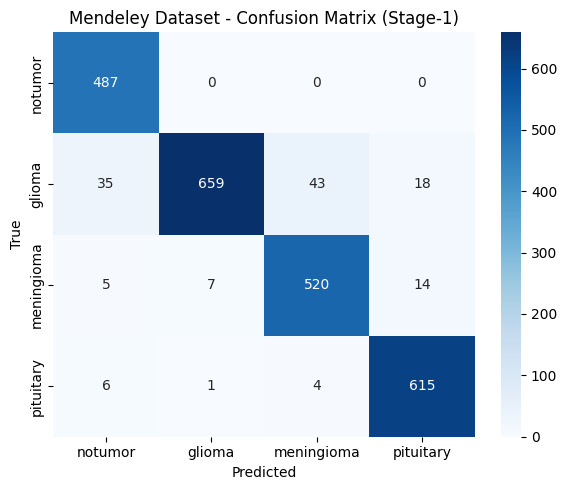


✅ Results saved to PDF: /kaggle/working/mendeley_stage1_results.pdf


In [8]:
# ==========================================================
# Mendeley Classification Evaluation (STAGE-1 MODEL)
# ==========================================================

from matplotlib.backends.backend_pdf import PdfPages

MENDELEY_PATH = "/kaggle/input/datasets/riyanka18/mendeley/Brain Tumor MRI Dataset (Glioma, Meningioma, Pitui/Epic and CSCR hospital Dataset/Epic and CSCR hospital Dataset/Test/"

PDF_PATH = "/kaggle/working/mendeley_stage1_results.pdf"

# ----------------------------
# Build DataFrame
# ----------------------------
mendeley_images, mendeley_labels = [], []

for cls_name, cls_id in class_map.items():
    folder = os.path.join(MENDELEY_PATH, cls_name)

    for img_path in glob.glob(os.path.join(folder, "*")):
        mendeley_images.append(img_path)
        mendeley_labels.append(cls_id)

mendeley_df = pd.DataFrame({
    "image": mendeley_images,
    "label": mendeley_labels
})

print("Total Mendeley samples:", len(mendeley_df))
print(mendeley_df.label.value_counts().sort_index())


# ----------------------------
# Dataset
# ----------------------------
class ClassificationDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.loc[idx]

        img = cv2.imread(row.image)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if self.transform:
            img = self.transform(image=img)["image"]

        return img, torch.tensor(row.label)


# ----------------------------
# Transforms (same as Stage-1)
# ----------------------------
test_tfms = A.Compose([
    A.Resize(IMG_MTL, IMG_MTL),
    A.Normalize(mean=(0.485,0.456,0.406),
                std=(0.229,0.224,0.225)),
    ToTensorV2()
])

test_loader = DataLoader(
    ClassificationDataset(mendeley_df, test_tfms),
    batch_size=8,
    shuffle=False,
    num_workers=2
)


# ----------------------------
# 🔥 Load STAGE-1 MODEL
# ----------------------------
model = MultiTaskSegFormer(num_classes=len(class_map)).to(device)
model.load_state_dict(torch.load(BEST_STAGE1_PATH, map_location=device))
model.eval()

print("✅ Loaded trained Stage-1 model")


# ----------------------------
# Evaluation
# ----------------------------
all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)

        cls_logits, _ = model(imgs, enable_seg=False)
        preds = torch.argmax(cls_logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())


# ----------------------------
# Metrics
# ----------------------------
acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds, average='macro', zero_division=0)
rec = recall_score(all_labels, all_preds, average='macro', zero_division=0)
f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)

print("\n================ Mendeley Classification Results (Stage-1) ================\n")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1 Score  : {f1:.4f}")


# ----------------------------
# Classification Report
# ----------------------------
class_names = list(class_map.keys())

report_str = classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    zero_division=0
)

print("\nClassification Report:\n")
print(report_str)


# ----------------------------
# Confusion Matrix
# ----------------------------
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True, fmt="d", cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Mendeley Dataset - Confusion Matrix (Stage-1)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()


# ==========================================================
# SAVE TO PDF
# ==========================================================
with PdfPages(PDF_PATH) as pdf:

    # Page 1 → Metrics + Report
    fig1 = plt.figure(figsize=(8, 10))
    plt.axis("off")

    text = (
        "Mendeley Classification Results (Stage-1)\n\n"
        f"Accuracy  : {acc:.4f}\n"
        f"Precision : {prec:.4f}\n"
        f"Recall    : {rec:.4f}\n"
        f"F1 Score  : {f1:.4f}\n\n"
        "Classification Report:\n\n"
        f"{report_str}"
    )

    plt.text(0.01, 0.99, text, va='top', family='monospace')
    pdf.savefig(fig1, bbox_inches='tight')
    plt.close(fig1)

    # Page 2 → Confusion Matrix
    fig2 = plt.figure(figsize=(6,5))
    sns.heatmap(
        cm,
        annot=True, fmt="d", cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.title("Confusion Matrix (Stage-1)")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()

    pdf.savefig(fig2, bbox_inches='tight')
    plt.close(fig2)

print(f"\n✅ Results saved to PDF: {PDF_PATH}")

In [12]:
# ==========================================================
# 🔥 STAGE-2 SEGMENTATION VISUALIZATION (50 TEST SAMPLES)
# ==========================================================

import random

VIS_SAMPLES = min(50, len(seg_test_df))   # 👈 safe
PDF_PATH = "/kaggle/working/stage2_segmentation_visualization_50.pdf"

# ----------------------------
# Load Stage-2 model
# ----------------------------
model = MultiTaskSegFormer(num_classes=len(class_map)).to(device)
model.load_state_dict(torch.load(STAGE2_CKPT_PATH, map_location=device))
model.eval()

print("✅ Stage-2 model loaded")

# ----------------------------
# Transform
# ----------------------------
vis_tfms = A.Compose([
    A.Resize(IMG_STAGE2, IMG_STAGE2),
    A.Normalize(mean=(0.485,0.456,0.406),
                std=(0.229,0.224,0.225)),
    ToTensorV2()
])

# ----------------------------
# Sample test rows
# ----------------------------
sample_df = seg_test_df.sample(VIS_SAMPLES, random_state=SEED).reset_index(drop=True)

# ----------------------------
# Overlay helper
# ----------------------------
def overlay_mask(image, mask, alpha=0.5):
    mask = (mask > 0.5).astype(np.uint8)

    colored = np.zeros_like(image)
    colored[:, :, 0] = mask * 255   # RED

    overlay = cv2.addWeighted(image, 1.0, colored, alpha, 0)
    return overlay

# ----------------------------
# Visualization (BIGGER layout)
# ----------------------------
from matplotlib.backends.backend_pdf import PdfPages

with PdfPages(PDF_PATH) as pdf:

    for i in range(len(sample_df)):

        row = sample_df.loc[i]

        # ---- Load image ----
        img = cv2.imread(row.image)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # ---- Load GT mask ----
        mask = cv2.imread(row.mask_path, 0)
        mask = cv2.resize(mask, (img.shape[1], img.shape[0]))
        mask = (mask > 127).astype(np.float32)

        # ---- Preprocess ----
        aug = vis_tfms(image=img, mask=mask)
        img_t = aug["image"].unsqueeze(0).to(device)

        # ---- Predict ----
        with torch.no_grad():
            _, seg_outputs = model(img_t)

            pred = seg_outputs[-1] if isinstance(seg_outputs, list) else seg_outputs
            pred = torch.sigmoid(pred)

            pred = pred.squeeze().cpu().numpy()

        pred_bin = (pred > 0.5).astype(np.float32)

        # ---- Resize back ----
        pred_bin = cv2.resize(pred_bin, (img.shape[1], img.shape[0]))

        # ---- Overlay ----
        overlay = overlay_mask(img, pred_bin)

        # ----------------------------
        # 🔥 BIGGER PLOT (2x2 GRID)
        # ----------------------------
        fig, axes = plt.subplots(2, 2, figsize=(8, 8))

        axes[0, 0].imshow(img)
        axes[0, 0].set_title("Image")
        axes[0, 0].axis("off")

        axes[0, 1].imshow(mask, cmap="gray")
        axes[0, 1].set_title("Ground Truth")
        axes[0, 1].axis("off")

        axes[1, 0].imshow(pred_bin, cmap="gray")
        axes[1, 0].set_title("Prediction")
        axes[1, 0].axis("off")

        axes[1, 1].imshow(overlay)
        axes[1, 1].set_title("Overlay")
        axes[1, 1].axis("off")

        plt.suptitle(
            f"Sample {i+1} | Class: {inv_class_map[row.label]}",
            fontsize=12
        )

        plt.tight_layout()
        pdf.savefig(fig, bbox_inches="tight")
        plt.close(fig)

print(f"\n✅ 50-sample visualization saved: {PDF_PATH}")

Some weights of BeitModel were not initialized from the model checkpoint at microsoft/beit-base-patch16-224-pt22k and are newly initialized: ['pooler.layernorm.bias', 'pooler.layernorm.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ Stage-2 model loaded

✅ 50-sample visualization saved: /kaggle/working/stage2_segmentation_visualization_50.pdf


In [11]:
# ==========================================================
# 🔥 STAGE-1 SEGMENTATION VISUALIZATION (TEST SET)
# ==========================================================

import random

VIS_SAMPLES = 12
PDF_PATH = "/kaggle/working/stage1_segmentation_visualization.pdf"

# ----------------------------
# Load Stage-1 model
# ----------------------------
model = MultiTaskSegFormer(num_classes=len(class_map)).to(device)
model.load_state_dict(torch.load(BEST_STAGE1_PATH, map_location=device))
model.eval()

print("✅ Stage-1 model loaded")

# ----------------------------
# Transform (Stage-1 size)
# ----------------------------
vis_tfms = A.Compose([
    A.Resize(IMG_MTL, IMG_MTL),   # 👈 Stage-1 size (224)
    A.Normalize(mean=(0.485,0.456,0.406),
                std=(0.229,0.224,0.225)),
    ToTensorV2()
])

# ----------------------------
# Sample same test rows (important!)
# ----------------------------
sample_df = seg_test_df.sample(VIS_SAMPLES, random_state=SEED).reset_index(drop=True)

# ----------------------------
# Overlay helper
# ----------------------------
def overlay_mask(image, mask, alpha=0.5):
    mask = (mask > 0.5).astype(np.uint8)

    colored = np.zeros_like(image)
    colored[:, :, 0] = mask * 255   # RED

    overlay = cv2.addWeighted(image, 1.0, colored, alpha, 0)
    return overlay

# ----------------------------
# Visualization
# ----------------------------
from matplotlib.backends.backend_pdf import PdfPages

with PdfPages(PDF_PATH) as pdf:

    for i in range(len(sample_df)):

        row = sample_df.loc[i]

        # ---- Load image ----
        img = cv2.imread(row.image)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # ---- Load GT mask ----
        mask = cv2.imread(row.mask_path, 0)
        mask = cv2.resize(mask, (img.shape[1], img.shape[0]))
        mask = (mask > 127).astype(np.float32)

        # ---- Preprocess ----
        aug = vis_tfms(image=img, mask=mask)
        img_t = aug["image"].unsqueeze(0).to(device)

        # ---- Predict ----
        with torch.no_grad():
            _, seg_outputs = model(img_t)

            pred = seg_outputs[-1] if isinstance(seg_outputs, list) else seg_outputs
            pred = torch.sigmoid(pred)

            pred = pred.squeeze().cpu().numpy()

        pred_bin = (pred > 0.5).astype(np.float32)

        # ---- Resize back to original ----
        pred_bin = cv2.resize(pred_bin, (img.shape[1], img.shape[0]))

        # ---- Overlay ----
        overlay = overlay_mask(img, pred_bin)

        # ---- Plot ----
        fig, axes = plt.subplots(1, 4, figsize=(16, 4))

        axes[0].imshow(img)
        axes[0].set_title("Image")
        axes[0].axis("off")

        axes[1].imshow(mask, cmap="gray")
        axes[1].set_title("Ground Truth")
        axes[1].axis("off")

        axes[2].imshow(pred_bin, cmap="gray")
        axes[2].set_title("Prediction (Stage-1)")
        axes[2].axis("off")

        axes[3].imshow(overlay)
        axes[3].set_title("Overlay (Stage-1)")
        axes[3].axis("off")

        plt.suptitle(f"Class: {inv_class_map[row.label]}", fontsize=12)

        plt.tight_layout()
        pdf.savefig(fig, bbox_inches="tight")
        plt.close(fig)

print(f"\n✅ Stage-1 Visualization saved: {PDF_PATH}")

Some weights of BeitModel were not initialized from the model checkpoint at microsoft/beit-base-patch16-224-pt22k and are newly initialized: ['pooler.layernorm.bias', 'pooler.layernorm.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ Stage-1 model loaded

✅ Stage-1 Visualization saved: /kaggle/working/stage1_segmentation_visualization.pdf


In [11]:
# ======================================================
# QUALITATIVE VIS: MENDELEY (CLASSIFICATION ONLY) - STAGE-2
# ======================================================

from matplotlib.backends.backend_pdf import PdfPages

def visualize_mendeley_classification_only(
    model,
    class_map,
    mendeley_path,
    transform,
    num_samples_per_class=2,
    device=device,
    only_errors=False,
    dataset_name="Mendeley (Stage-2 Classification)",
    save_path="mendeley_classification_stage2.pdf"
):
    import random
    import glob
    import os
    import matplotlib.pyplot as plt

    model.eval()

    # ----------------------------------
    # Build sample list
    # ----------------------------------
    samples = []

    for cls_name, cls_id in class_map.items():
        folder = os.path.join(mendeley_path, cls_name)
        imgs = glob.glob(os.path.join(folder, "*"))

        if len(imgs) == 0:
            continue

        selected = random.sample(imgs, min(num_samples_per_class, len(imgs)))

        for p in selected:
            samples.append({
                "image": p,
                "label": cls_id,
                "class_name": cls_name
            })

    # ----------------------------------
    # Inference (CLASSIFICATION ONLY)
    # ----------------------------------
    results = []

    with torch.no_grad():
        for sample in samples:
            img = cv2.cvtColor(cv2.imread(sample["image"]), cv2.COLOR_BGR2RGB)

            x = transform(image=img)["image"].unsqueeze(0).to(device)

            # ✅ ONLY classification branch
            cls_logits, _ = model(x, enable_seg=False)

            probs = torch.softmax(cls_logits, dim=1)
            pred_id = probs.argmax().item()
            confidence = probs.max().item()

            pred_name = list(class_map.keys())[pred_id]

            results.append({
                "img": img,
                "gt": sample["class_name"],
                "pred": pred_name,
                "conf": confidence,
                "correct": (pred_name == sample["class_name"])
            })

    # ----------------------------------
    # Filter (optional)
    # ----------------------------------
    if only_errors:
        results = [r for r in results if not r["correct"]]
        if len(results) == 0:
            print("🎉 No misclassifications found!")
            return

    # ----------------------------------
    # Save to PDF
    # ----------------------------------
    with PdfPages(save_path) as pdf:

        for r in results:
            plt.figure(figsize=(5, 5))

            title = (
                f"{dataset_name}\n"
                f"GT: {r['gt']} | Pred: {r['pred']}\n"
                f"Conf: {r['conf']:.3f}"
            )

            plt.imshow(r["img"])
            plt.title(title,
                      color=("green" if r["correct"] else "red"),
                      fontsize=10)
            plt.axis("off")

            pdf.savefig(bbox_inches="tight")
            plt.close()

    print(f"✅ Classification PDF saved to: {save_path}")

stage2_model = MultiTaskSegFormer(num_classes=len(class_map)).to(device)
stage2_model.load_state_dict(torch.load(STAGE2_CKPT_PATH, map_location=device))

visualize_mendeley_classification_only(
    model=stage2_model,
    class_map=class_map,
    mendeley_path=MENDELEY_PATH,
    transform=test_tfms,
    num_samples_per_class=2,
    device=device,
    only_errors=False,   # set True for only mistakes
    save_path="mendeley_stage2_classification.pdf"
)

Some weights of BeitModel were not initialized from the model checkpoint at microsoft/beit-base-patch16-224-pt22k and are newly initialized: ['pooler.layernorm.bias', 'pooler.layernorm.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ Classification PDF saved to: mendeley_stage2_classification.pdf


# segmentation results

In [ ]:
# ==========================================================
# STAGE-2 TEST EVALUATION ON 209 SEGMENTATION TEST SAMPLES
# Tumor Suppression Rule:
# If classifier predicts No-tumor (class 0) -> force empty mask
# ==========================================================

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.metrics import classification_report
import torch
import torch.nn.functional as F

TEST_PDF_PATH = "/kaggle/working/stage2_test_209_results.pdf"
VIS_SAMPLES = 50   # number of pages to visualize

# ----------------------------------------------------------
# Load best Stage-2 model
# ----------------------------------------------------------
stage2_model = MultiTaskSegFormer(num_classes=len(class_map)).to(device)
stage2_model.load_state_dict(torch.load(STAGE2_CKPT_PATH, map_location=device))
stage2_model.eval()

# ----------------------------------------------------------
# Test Dataset
# ----------------------------------------------------------
test_loader = DataLoader(
    SegOnlyDataset(seg_test_df, val_tfms_stage2),
    batch_size=1,
    shuffle=False
)

# ----------------------------------------------------------
# Dice metric
# ----------------------------------------------------------
def dice_score_binary(pred, target, eps=1e-6):
    pred = pred.astype(np.float32)
    target = target.astype(np.float32)

    inter = (pred * target).sum()
    union = pred.sum() + target.sum()

    return (2 * inter + eps) / (union + eps)

# ----------------------------------------------------------
# Evaluate
# ----------------------------------------------------------
all_dice = []
y_true = []
y_pred = []

pdf = PdfPages(TEST_PDF_PATH)

with torch.no_grad():

    for idx, (img, _, mask_gt) in enumerate(test_loader):

        img = img.to(device)
        mask_gt = mask_gt.squeeze().cpu().numpy()

        # --------------------------------------
        # Forward pass
        # --------------------------------------
        cls_logits, seg_outputs = stage2_model(img)

        pred_class = cls_logits.argmax(1).item()

        seg_pred = seg_outputs[-1] if isinstance(seg_outputs, list) else seg_outputs
        seg_pred = torch.sigmoid(seg_pred).squeeze().cpu().numpy()
        seg_pred = (seg_pred > 0.5).astype(np.uint8)

        # --------------------------------------
        # Tumor suppression rule
        # --------------------------------------
        if pred_class == 0:
            seg_pred[:] = 0

        # --------------------------------------
        # Dice
        # --------------------------------------
        dice = dice_score_binary(seg_pred, mask_gt)
        all_dice.append(dice)

        true_label = int(seg_test_df.iloc[idx]["label"])

        y_true.append(true_label)
        y_pred.append(pred_class)

        # --------------------------------------
        # Visualization
        # --------------------------------------
        if idx < VIS_SAMPLES:

            img_np = img.squeeze().permute(1,2,0).cpu().numpy()
            img_np = img_np * np.array([0.229,0.224,0.225]) + np.array([0.485,0.456,0.406])
            img_np = np.clip(img_np,0,1)

            overlay = img_np.copy()
            overlay[seg_pred > 0] = [1,0,0]   # red mask

            fig, ax = plt.subplots(1,4, figsize=(16,4))

            ax[0].imshow(img_np)
            ax[0].set_title(
                f"Pred: {inv_class_map[pred_class].title()} | Dice: {dice:.3f}"
            )
            ax[0].axis("off")

            ax[1].imshow(mask_gt, cmap="gray")
            ax[1].set_title("GT Mask")
            ax[1].axis("off")

            ax[2].imshow(seg_pred, cmap="gray")
            ax[2].set_title("Pred Mask")
            ax[2].axis("off")

            ax[3].imshow(overlay)
            ax[3].set_title("Overlay")
            ax[3].axis("off")

            plt.tight_layout()
            pdf.savefig(fig)
            plt.close()

pdf.close()

# ----------------------------------------------------------
# Final Metrics
# ----------------------------------------------------------
print("="*60)
print("STAGE-2 TEST RESULTS (209 Segmentation Samples)")
print("="*60)
print(f"Mean Dice Score : {np.mean(all_dice):.4f}")
print(f"Median Dice     : {np.median(all_dice):.4f}")
print(f"Min Dice        : {np.min(all_dice):.4f}")
print(f"Max Dice        : {np.max(all_dice):.4f}")
print("="*60)

print("\nClassification Report (Classifier branch only):")
print(classification_report(
    y_true,
    y_pred,
    target_names=list(class_map.keys()),
    zero_division=0
))

print(f"\nSaved PDF -> {TEST_PDF_PATH}")

# Baseline


Training ResNet18+UNet


100%|██████████| 999/999 [00:54<00:00, 18.37it/s]


Epoch 1/15 completed


100%|██████████| 999/999 [00:52<00:00, 18.97it/s]


Epoch 2/15 completed


...

100%|██████████| 999/999 [05:53<00:00,  2.82it/s]


Epoch 14/15 completed


100%|██████████| 999/999 [05:55<00:00,  2.81it/s]

Epoch 15/15 completed


               Model  Accuracy        F1      Dice       IoU
0      ResNet18+UNet  0.977253  0.976093  0.856835  0.781132
1  EfficientNet+UNet  0.983377  0.983168  0.880048  0.813406
2           BEiT+FCN  0.951006  0.949389  0.594283  0.480382
3     BEiT+SegFormer  0.874016  0.863813  0.735850  0.628253


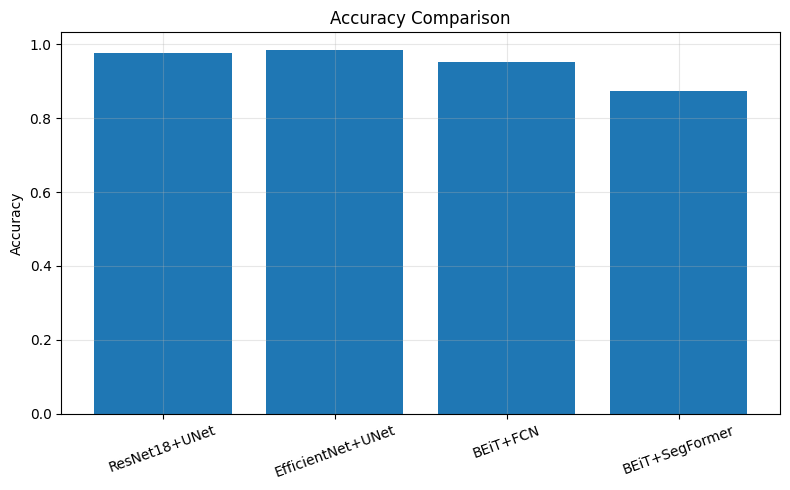

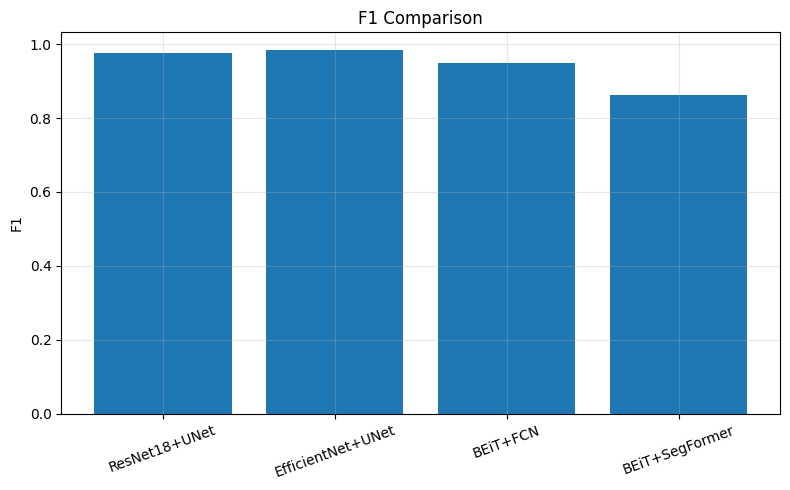

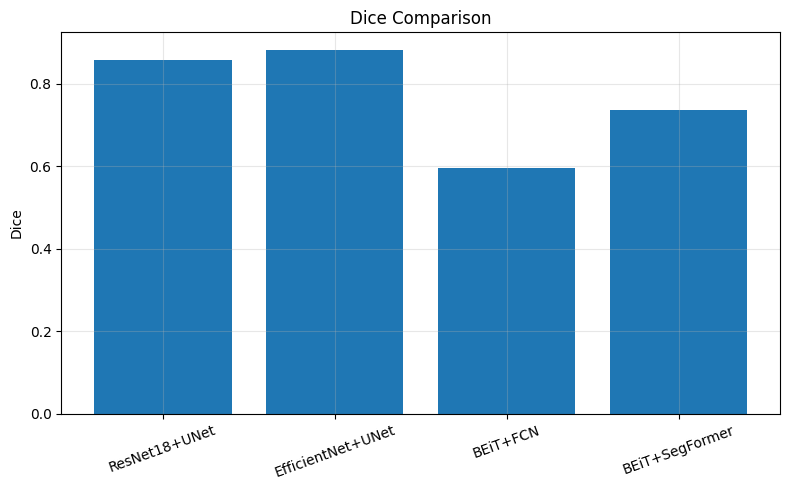

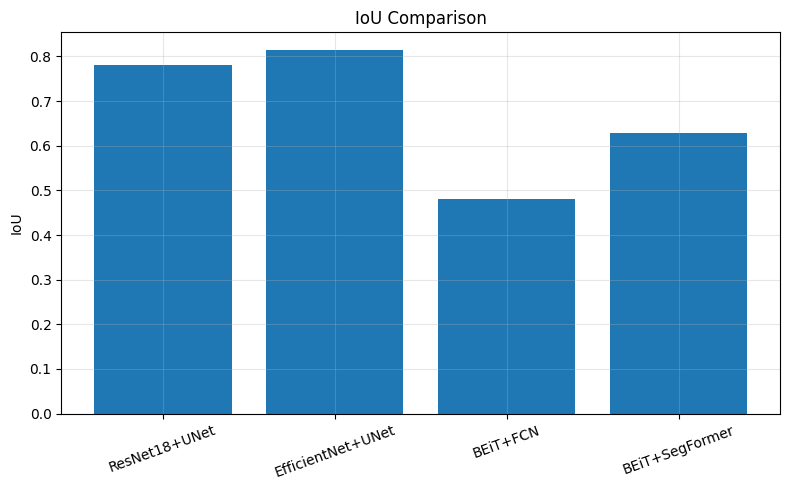


All baselines completed.


In [5]:
# ============================================================
# COMPLETE BASELINE COMPARISON FRAMEWORK (UPDATED)
# Models:
# 1. ResNet18 + UNet
# 2. EfficientNet + UNet
# 3. BEiT + FCN
# 4. BEiT + SegFormer  <-- YOUR PROPOSED MODEL
# Uses existing train_loader / val_loader
# Runs ALL for 15 Epochs
# ============================================================

import os, copy, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models

from sklearn.metrics import accuracy_score, f1_score
from transformers import BeitModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SAVE_DIR = "/kaggle/working/baseline_results"
os.makedirs(SAVE_DIR, exist_ok=True)

NUM_CLASSES = 4
EPOCHS = 15

# ============================================================
# METRICS
# ============================================================

def dice_score(pred, target, eps=1e-6):
    pred = (torch.sigmoid(pred) > 0.5).float()
    inter = (pred * target).sum(dim=(1,2,3))
    union = pred.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3))
    return ((2*inter+eps)/(union+eps)).mean().item()

def iou_score(pred, target, eps=1e-6):
    pred = (torch.sigmoid(pred) > 0.5).float()
    inter = (pred * target).sum(dim=(1,2,3))
    union = (pred + target - pred*target).sum(dim=(1,2,3))
    return ((inter+eps)/(union+eps)).mean().item()

# ============================================================
# COMMON BLOCKS
# ============================================================

class UpBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()

        self.up = nn.ConvTranspose2d(in_ch, out_ch, 2, stride=2)

        self.conv = nn.Sequential(
            nn.Conv2d(out_ch + skip_ch, out_ch, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.ReLU()
        )

    def forward(self, x, skip):
        x = self.up(x)

        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode='bilinear')

        x = torch.cat([x, skip], dim=1)
        return self.conv(x)

# ============================================================
# MODEL 1 : RESNET18 + UNET
# ============================================================

class ResNet18_UNet(nn.Module):
    def __init__(self):
        super().__init__()

        backbone = models.resnet18(weights="DEFAULT")

        self.stem = nn.Sequential(
            backbone.conv1,
            backbone.bn1,
            backbone.relu
        )

        self.pool = backbone.maxpool
        self.l1 = backbone.layer1
        self.l2 = backbone.layer2
        self.l3 = backbone.layer3
        self.l4 = backbone.layer4

        self.up1 = UpBlock(512,256,256)
        self.up2 = UpBlock(256,128,128)
        self.up3 = UpBlock(128,64,64)

        self.seg_head = nn.Conv2d(64,1,1)
        self.cls_head = nn.Linear(512,NUM_CLASSES)

    def forward(self,x):

        x0 = self.stem(x)
        x1 = self.l1(self.pool(x0))
        x2 = self.l2(x1)
        x3 = self.l3(x2)
        x4 = self.l4(x3)

        pooled = F.adaptive_avg_pool2d(x4,1).flatten(1)
        cls = self.cls_head(pooled)

        y = self.up1(x4,x3)
        y = self.up2(y,x2)
        y = self.up3(y,x1)

        seg = self.seg_head(y)
        seg = F.interpolate(seg,size=x.shape[-2:],mode='bilinear')

        return cls, seg

# ============================================================
# MODEL 2 : EFFICIENTNET + UNET
# ============================================================

class EfficientNet_UNet(nn.Module):
    def __init__(self):
        super().__init__()

        net = models.efficientnet_b0(weights="DEFAULT")
        self.features = net.features

        self.up1 = UpBlock(1280,112,256)
        self.up2 = UpBlock(256,40,128)
        self.up3 = UpBlock(128,24,64)

        self.seg_head = nn.Conv2d(64,1,1)
        self.cls_head = nn.Linear(1280,NUM_CLASSES)

    def forward(self,x):

        f1 = self.features[:3](x)
        f2 = self.features[3:4](f1)
        f3 = self.features[4:6](f2)
        f4 = self.features[6:](f3)

        pooled = F.adaptive_avg_pool2d(f4,1).flatten(1)
        cls = self.cls_head(pooled)

        y = self.up1(f4,f3)
        y = self.up2(y,f2)
        y = self.up3(y,f1)

        seg = self.seg_head(y)
        seg = F.interpolate(seg,size=x.shape[-2:],mode='bilinear')

        return cls, seg

# ============================================================
# MODEL 3 : BEiT + FCN
# ============================================================

class BEiT_FCN(nn.Module):
    def __init__(self):
        super().__init__()

        self.backbone = BeitModel.from_pretrained(
            "microsoft/beit-base-patch16-224-pt22k"
        )

        self.cls_head = nn.Linear(768, NUM_CLASSES)

        self.seg_head = nn.Sequential(
            nn.Conv2d(768,256,3,padding=1),
            nn.ReLU(),
            nn.Conv2d(256,1,1)
        )

    def forward(self,x):

        out = self.backbone(x).last_hidden_state

        cls_token = out[:,0]
        patch = out[:,1:]

        B,N,C = patch.shape
        H = W = int(N**0.5)

        feat = patch.permute(0,2,1).reshape(B,C,H,W)

        cls = self.cls_head(cls_token)

        seg = self.seg_head(feat)
        seg = F.interpolate(seg,size=x.shape[-2:],mode='bilinear')

        return cls, seg

# ============================================================
# MODEL 4 : BEiT + SEGFORMER
# ============================================================

class SegFormerDecoder(nn.Module):
    def __init__(self, in_ch=768, embed=256):
        super().__init__()

        self.proj1 = nn.Conv2d(in_ch, embed, 1)
        self.proj2 = nn.Conv2d(in_ch, embed, 1)
        self.proj3 = nn.Conv2d(in_ch, embed, 1)
        self.proj4 = nn.Conv2d(in_ch, embed, 1)

        self.fuse = nn.Sequential(
            nn.Conv2d(embed*4, embed, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(embed, embed, 3, padding=1),
            nn.ReLU()
        )

        self.head = nn.Conv2d(embed,1,1)

    def forward(self, feats):

        target = feats[0].shape[-2:]

        p = []
        projs = [self.proj1,self.proj2,self.proj3,self.proj4]

        for i,f in enumerate(feats):
            x = projs[i](f)
            x = F.interpolate(x,size=target,mode='bilinear')
            p.append(x)

        x = torch.cat(p,dim=1)
        x = self.fuse(x)

        return self.head(x)

class BEiT_SegFormer(nn.Module):
    def __init__(self):
        super().__init__()

        self.backbone = BeitModel.from_pretrained(
            "microsoft/beit-base-patch16-224-pt22k",
            output_hidden_states=True
        )

        self.cls_head = nn.Linear(768, NUM_CLASSES)
        self.decoder = SegFormerDecoder()

    def tokens_to_map(self,t):
        t = t[:,1:,:]
        B,N,C = t.shape
        H=W=int(N**0.5)
        return t.permute(0,2,1).reshape(B,C,H,W)

    def forward(self,x):

        out = self.backbone(x)

        hs = out.hidden_states[-4:]

        feats = [self.tokens_to_map(h) for h in hs[::-1]]

        pooled = F.adaptive_avg_pool2d(feats[0],1).flatten(1)
        cls = self.cls_head(pooled)

        seg = self.decoder(feats)
        seg = F.interpolate(seg,size=x.shape[-2:],mode='bilinear')

        return cls, seg

# ============================================================
# MODEL FACTORY
# ============================================================

def get_model(name):

    if name=="ResNet18+UNet":
        return ResNet18_UNet()

    elif name=="EfficientNet+UNet":
        return EfficientNet_UNet()

    elif name=="BEiT+FCN":
        return BEiT_FCN()

    elif name=="BEiT+SegFormer":
        return BEiT_SegFormer()

# ============================================================
# TRAINING
# ============================================================

def train_model(model, epochs=EPOCHS):

    model.to(device)

    cls_loss_fn = nn.CrossEntropyLoss()
    seg_loss_fn = nn.BCEWithLogitsLoss()

    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

    for epoch in range(epochs):

        model.train()

        for imgs, labels, masks in tqdm(train_loader):

            imgs = imgs.to(device)
            labels = labels.to(device)
            masks = masks.to(device)

            cls_logits, seg_logits = model(imgs)

            valid_cls = labels != -1

            cls_loss = cls_loss_fn(
                cls_logits[valid_cls], labels[valid_cls]
            ) if valid_cls.any() else 0

            has_mask = masks.sum(dim=(1,2,3)) > 0

            seg_loss = seg_loss_fn(
                seg_logits[has_mask], masks[has_mask]
            ) if has_mask.any() else 0

            loss = cls_loss + seg_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        print(f"Epoch {epoch+1}/{epochs} completed")

    # ========================================================
    # VALIDATION
    # ========================================================

    model.eval()

    preds_all = []
    labels_all = []
    dices = []
    ious = []

    with torch.no_grad():

        for imgs, labels, masks in val_loader:

            imgs = imgs.to(device)
            labels = labels.to(device)
            masks = masks.to(device)

            cls_logits, seg_logits = model(imgs)

            valid_cls = labels != -1

            if valid_cls.any():
                pred = cls_logits[valid_cls].argmax(1)
                preds_all.extend(pred.cpu().numpy())
                labels_all.extend(labels[valid_cls].cpu().numpy())

            has_mask = masks.sum(dim=(1,2,3)) > 0

            if has_mask.any():
                dices.append(dice_score(seg_logits[has_mask], masks[has_mask]))
                ious.append(iou_score(seg_logits[has_mask], masks[has_mask]))

    acc = accuracy_score(labels_all, preds_all)
    f1  = f1_score(labels_all, preds_all, average="macro")
    dice = np.mean(dices)
    iou  = np.mean(ious)

    return acc, f1, dice, iou

# ============================================================
# RUN ALL MODELS
# ============================================================

model_names = [
    "ResNet18+UNet",
    "EfficientNet+UNet",
    "BEiT+FCN",
    "BEiT+SegFormer"
]

results = []

for name in model_names:

    print("\n==============================")
    print("Training", name)
    print("==============================")

    model = get_model(name)

    acc, f1, dice, iou = train_model(model)

    results.append([name,acc,f1,dice,iou])

# ============================================================
# RESULTS TABLE
# ============================================================

df = pd.DataFrame(
    results,
    columns=["Model","Accuracy","F1","Dice","IoU"]
)

print(df)

df.to_csv(f"{SAVE_DIR}/baseline_results.csv", index=False)

# ============================================================
# HISTOGRAMS
# ============================================================

metrics = ["Accuracy","F1","Dice","IoU"]

for metric in metrics:

    plt.figure(figsize=(8,5))
    plt.bar(df["Model"], df[metric])

    plt.title(f"{metric} Comparison")
    plt.ylabel(metric)
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=20)

    plt.tight_layout()
    plt.show()

print("\nAll baselines completed.")

In [7]:
# ============================================================
# FAIR BASELINE + ABLATION FRAMEWORK
# Includes:
# 1. ResNet18 + FCN              (weak CNN baseline)
# 2. ResNet18 + UNet             (strong CNN baseline)
# 3. BEiT + FCN                  (weak transformer baseline)
# 4. Vanilla BEiT + SegFormer    (plain transformer baseline)
# 5. Improved BEiT + SegFormer   (proposed)
# ============================================================

import os
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models

from transformers import BeitModel

from sklearn.metrics import accuracy_score, f1_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

NUM_CLASSES = 4
EPOCHS = 5

# ============================================================
# METRICS
# ============================================================

def dice_score(pred, target, eps=1e-6):

    pred = (torch.sigmoid(pred) > 0.5).float()

    inter = (pred * target).sum(dim=(1,2,3))
    union = pred.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3))

    return ((2*inter + eps)/(union + eps)).mean().item()


def iou_score(pred, target, eps=1e-6):

    pred = (torch.sigmoid(pred) > 0.5).float()

    inter = (pred * target).sum(dim=(1,2,3))
    union = (pred + target - pred*target).sum(dim=(1,2,3))

    return ((inter + eps)/(union + eps)).mean().item()

# ============================================================
# LOSSES
# ============================================================

class DiceFocalLoss(nn.Module):

    def __init__(self, alpha=0.8, gamma=2):
        super().__init__()

        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):

        probs = torch.sigmoid(logits)

        inter = (probs * targets).sum(dim=(1,2,3))
        union = probs.sum(dim=(1,2,3)) + targets.sum(dim=(1,2,3))

        dice = 1 - ((2*inter + 1)/(union + 1))

        bce = F.binary_cross_entropy_with_logits(
            logits, targets, reduction='none'
        )

        pt = torch.exp(-bce)

        focal = self.alpha * (1-pt)**self.gamma * bce

        return dice.mean() + focal.mean()

# ============================================================
# SIMPLE FCN HEAD
# ============================================================

class FCNHead(nn.Module):

    def __init__(self, in_ch):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(in_ch, 256, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(256, 1, 1)
        )

    def forward(self, x):
        return self.block(x)

# ============================================================
# CBAM
# ============================================================

class CBAM(nn.Module):

    def __init__(self, channels, reduction=16):
        super().__init__()

        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        self.fc = nn.Sequential(
            nn.Conv2d(channels, channels // reduction, 1, bias=False),
            nn.ReLU(),
            nn.Conv2d(channels // reduction, channels, 1, bias=False)
        )

        self.spatial = nn.Sequential(
            nn.Conv2d(2,1,7,padding=3,bias=False),
            nn.Sigmoid()
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):

        avg = self.fc(self.avg_pool(x))
        mx  = self.fc(self.max_pool(x))

        x = x * self.sigmoid(avg + mx)

        avg = torch.mean(x, dim=1, keepdim=True)
        mx,_ = torch.max(x, dim=1, keepdim=True)

        x = x * self.spatial(torch.cat([avg,mx], dim=1))

        return x

# ============================================================
# RESNET18 + FCN (WEAK BASELINE)
# ============================================================

class ResNet18_FCN(nn.Module):

    def __init__(self):
        super().__init__()

        net = models.resnet18(weights="DEFAULT")

        self.encoder = nn.Sequential(*list(net.children())[:-2])

        self.cls_head = nn.Linear(512, NUM_CLASSES)

        self.seg_head = FCNHead(512)

    def forward(self, x):

        feat = self.encoder(x)

        pooled = F.adaptive_avg_pool2d(feat,1).flatten(1)

        cls = self.cls_head(pooled)

        seg = self.seg_head(feat)

        seg = F.interpolate(seg, size=x.shape[-2:], mode='bilinear')

        return cls, seg

# ============================================================
# RESNET18 + UNET
# ============================================================

class UpBlock(nn.Module):

    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()

        self.up = nn.ConvTranspose2d(in_ch, out_ch, 2, stride=2)

        self.conv = nn.Sequential(
            nn.Conv2d(out_ch + skip_ch, out_ch, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.ReLU()
        )

    def forward(self, x, skip):

        x = self.up(x)

        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:])

        x = torch.cat([x, skip], dim=1)

        return self.conv(x)


class ResNet18_UNet(nn.Module):

    def __init__(self):
        super().__init__()

        backbone = models.resnet18(weights="DEFAULT")

        self.stem = nn.Sequential(
            backbone.conv1,
            backbone.bn1,
            backbone.relu
        )

        self.pool = backbone.maxpool

        self.l1 = backbone.layer1
        self.l2 = backbone.layer2
        self.l3 = backbone.layer3
        self.l4 = backbone.layer4

        self.up1 = UpBlock(512,256,256)
        self.up2 = UpBlock(256,128,128)
        self.up3 = UpBlock(128,64,64)

        self.seg_head = nn.Conv2d(64,1,1)

        self.cls_head = nn.Linear(512, NUM_CLASSES)

    def forward(self, x):

        x0 = self.stem(x)

        x1 = self.l1(self.pool(x0))
        x2 = self.l2(x1)
        x3 = self.l3(x2)
        x4 = self.l4(x3)

        pooled = F.adaptive_avg_pool2d(x4,1).flatten(1)

        cls = self.cls_head(pooled)

        y = self.up1(x4,x3)
        y = self.up2(y,x2)
        y = self.up3(y,x1)

        seg = self.seg_head(y)

        seg = F.interpolate(seg, size=x.shape[-2:], mode='bilinear')

        return cls, seg

# ============================================================
# BEIT + FCN
# ============================================================

class BEiT_FCN(nn.Module):

    def __init__(self):
        super().__init__()

        self.backbone = BeitModel.from_pretrained(
            "microsoft/beit-base-patch16-224-pt22k"
        )

        self.cls_head = nn.Linear(768, NUM_CLASSES)

        self.seg_head = FCNHead(768)

    def forward(self, x):

        out = self.backbone(x).last_hidden_state

        cls_token = out[:,0]
        patch = out[:,1:]

        B,N,C = patch.shape

        H = W = int(N**0.5)

        feat = patch.permute(0,2,1).reshape(B,C,H,W)

        cls = self.cls_head(cls_token)

        seg = self.seg_head(feat)

        seg = F.interpolate(seg, size=x.shape[-2:], mode='bilinear')

        return cls, seg

# ============================================================
# VANILLA BEIT + SEGFORMER
# ============================================================

class VanillaSegFormer(nn.Module):

    def __init__(self, embed=256):
        super().__init__()

        self.proj = nn.ModuleList([
            nn.Conv2d(768, embed, 1)
            for _ in range(4)
        ])

        self.fuse = nn.Sequential(
            nn.Conv2d(embed*4, embed, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(embed, 1, 1)
        )

    def forward(self, feats):

        target = feats[0].shape[-2:]

        p = []

        for i,f in enumerate(feats):

            x = self.proj[i](f)

            x = F.interpolate(x, size=target, mode='bilinear')

            p.append(x)

        x = torch.cat(p, dim=1)

        return self.fuse(x)


class BEiT_SegFormer(nn.Module):

    def __init__(self):
        super().__init__()

        self.backbone = BeitModel.from_pretrained(
            "microsoft/beit-base-patch16-224-pt22k",
            output_hidden_states=True
        )

        self.cls_head = nn.Linear(768, NUM_CLASSES)

        self.decoder = VanillaSegFormer()

    def tokens_to_map(self, t):

        t = t[:,1:,:]

        B,N,C = t.shape

        H = W = int(N**0.5)

        return t.permute(0,2,1).reshape(B,C,H,W)

    def forward(self, x):

        out = self.backbone(x)

        hs = out.hidden_states[-4:]

        feats = [self.tokens_to_map(h) for h in hs[::-1]]

        pooled = F.adaptive_avg_pool2d(feats[0],1).flatten(1)

        cls = self.cls_head(pooled)

        seg = self.decoder(feats)

        seg = F.interpolate(seg, size=x.shape[-2:], mode='bilinear')

        return cls, seg

# ============================================================
# IMPROVED BEIT + SEGFORMER (PROPOSED)
# ============================================================

class ImprovedSegFormer(nn.Module):

    def __init__(self, embed=512):
        super().__init__()

        self.proj = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(768, embed, 1),
                nn.BatchNorm2d(embed),
                nn.ReLU()
            )
            for _ in range(4)
        ])

        self.cbam = nn.ModuleList([
            CBAM(embed)
            for _ in range(4)
        ])

        self.fuse = nn.Sequential(
            nn.Conv2d(embed*4, embed, 3, padding=1),
            nn.BatchNorm2d(embed),
            nn.ReLU(),

            nn.Conv2d(embed, embed, 3, padding=1),
            nn.BatchNorm2d(embed),
            nn.ReLU()
        )

        self.cbam_fuse = CBAM(embed)

        self.head = nn.Conv2d(embed,1,1)

    def forward(self, feats):

        target = feats[0].shape[-2:]

        p = []

        for i,f in enumerate(feats):

            x = self.proj[i](f)

            x = self.cbam[i](x)

            x = F.interpolate(x, size=target, mode='bilinear')

            p.append(x)

        x = torch.cat(p, dim=1)

        x = self.fuse(x)

        x = self.cbam_fuse(x)

        return self.head(x)


class Improved_BEiT_SegFormer(nn.Module):

    def __init__(self):
        super().__init__()

        self.backbone = BeitModel.from_pretrained(
            "microsoft/beit-base-patch16-224-pt22k",
            output_hidden_states=True
        )

        self.cls_head = nn.Linear(768, NUM_CLASSES)

        self.decoder = ImprovedSegFormer()

    def tokens_to_map(self, t):

        t = t[:,1:,:]

        B,N,C = t.shape

        H = W = int(N**0.5)

        return t.permute(0,2,1).reshape(B,C,H,W)

    def forward(self, x):

        out = self.backbone(x)

        hs = out.hidden_states[-4:]

        feats = [self.tokens_to_map(h) for h in hs[::-1]]

        pooled = F.adaptive_avg_pool2d(feats[0],1).flatten(1)

        cls = self.cls_head(pooled)

        seg = self.decoder(feats)

        seg = F.interpolate(seg, size=x.shape[-2:], mode='bilinear')

        return cls, seg

# ============================================================
# MODEL FACTORY
# ============================================================

def get_model(name):

    if name == "ResNet18+FCN":
        return ResNet18_FCN()

    elif name == "ResNet18+UNet":
        return ResNet18_UNet()

    elif name == "BEiT+FCN":
        return BEiT_FCN()

    elif name == "BEiT+SegFormer":
        return BEiT_SegFormer()

    elif name == "Improved BEiT+SegFormer":
        return Improved_BEiT_SegFormer()

# ============================================================
# TRAIN FUNCTION
# ============================================================

def train_model(model, model_name):

    model.to(device)

    cls_loss_fn = nn.CrossEntropyLoss()

    if "Improved" in model_name:
        seg_loss_fn = DiceFocalLoss()
    else:
        seg_loss_fn = nn.BCEWithLogitsLoss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=1e-4 if "ResNet" in model_name else 5e-5
    )

    for epoch in range(EPOCHS):

        model.train()

        for imgs, labels, masks in tqdm(train_loader):

            imgs = imgs.to(device)
            labels = labels.to(device)
            masks = masks.to(device)

            cls_logits, seg_logits = model(imgs)

            valid_cls = labels != -1

            cls_loss = cls_loss_fn(
                cls_logits[valid_cls],
                labels[valid_cls]
            ) if valid_cls.any() else 0

            has_mask = masks.sum(dim=(1,2,3)) > 0

            seg_loss = seg_loss_fn(
                seg_logits[has_mask],
                masks[has_mask]
            ) if has_mask.any() else 0

            if "Improved" in model_name:
                loss = cls_loss + 1.0 * seg_loss
            else:
                loss = cls_loss + 0.3 * seg_loss

            optimizer.zero_grad()

            loss.backward()

            optimizer.step()

        print(f"{model_name} Epoch {epoch+1}/{EPOCHS}")

    # ========================================================
    # VALIDATION
    # ========================================================

    model.eval()

    preds_all = []
    labels_all = []

    dices = []
    ious = []

    with torch.no_grad():

        for imgs, labels, masks in val_loader:

            imgs = imgs.to(device)
            labels = labels.to(device)
            masks = masks.to(device)

            cls_logits, seg_logits = model(imgs)

            valid_cls = labels != -1

            if valid_cls.any():

                pred = cls_logits[valid_cls].argmax(1)

                preds_all.extend(pred.cpu().numpy())

                labels_all.extend(labels[valid_cls].cpu().numpy())

            has_mask = masks.sum(dim=(1,2,3)) > 0

            if has_mask.any():

                dices.append(
                    dice_score(
                        seg_logits[has_mask],
                        masks[has_mask]
                    )
                )

                ious.append(
                    iou_score(
                        seg_logits[has_mask],
                        masks[has_mask]
                    )
                )

    acc = accuracy_score(labels_all, preds_all)

    f1 = f1_score(labels_all, preds_all, average='macro')

    dice = np.mean(dices)

    iou = np.mean(ious)

    return acc, f1, dice, iou

# ============================================================
# RUN EXPERIMENTS
# ============================================================

model_names = [
    "ResNet18+FCN",
    "ResNet18+UNet",
    "BEiT+FCN",
    "BEiT+SegFormer",
    "Improved BEiT+SegFormer"
]

results = []

for name in model_names:

    print("\n==============================")
    print("Training:", name)
    print("==============================")

    model = get_model(name)

    acc, f1, dice, iou = train_model(model, name)

    results.append([name, acc, f1, dice, iou])

# ============================================================
# RESULTS
# ============================================================

df = pd.DataFrame(
    results,
    columns=["Model","Accuracy","F1","Dice","IoU"]
)

print(df)

df.to_csv("/kaggle/working/fair_baseline_results.csv", index=False)


Training: ResNet18+FCN


AcceleratorError: CUDA error: device-side assert triggered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.
